# Motor de Stress Testing en Python
## Escenarios de Estrés y Cambios de Régimen de Mercado

**Práctica B2-2 - Módulo de Gestión de Riesgos**


| | |
|---|---|
| **Autor** | Albert Martin y Raúl Rodriguez |
| **Fecha** | Febrero 2026 |
| **Periodo de datos** | 01-01-2006 a la fecha |
|||


In [1]:
# Descomentar en Google Colab:
!pip install hmmlearn yfinance -q



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ALBER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## Fase 0.1: Configuración y librerías

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from datetime import datetime
import yfinance as yf
from scipy import stats
from scipy.stats import skew, kurtosis, kendalltau, t as t_dist
from scipy.special import gammaln
from scipy.optimize import minimize_scalar
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# Colores segun enunciado: Blanco=Calma, Azul=Crisis
COLOR_CALMA = "#FFFFFF"
COLOR_CRISIS = "#1A5276"
COLOR_CALMA_FILL = "#E8F8F5"  # verde suave para fondo calma

SEED = 42
np.random.seed(SEED)

START_DATE = "2006-01-01"
END_DATE = datetime.now().strftime("%Y-%m-%d")
N_SIMULATIONS = 10_000
HORIZON_DAYS = 126  # 6 meses habiles

# Flag de método de simulación
USE_COPULAS = True  # True=t-cópula (lento), False=bootstrap (rapido)

# Trazabilidad de fuentes por bloque de datos
DATA_SOURCES = {
    "Acciones/ETFs": "Yahoo Finance (yfinance, precios ajustados)",
    "S&P 500": "Yahoo Finance (^GSPC)",
    "Tipos 10Y/5Y": "Yahoo Finance (^TNX/^FVX; fallback mediante ETFs IEF/SHY)",
    "Credito y liquidez": "Proxies de mercado via ETFs (HYG, LQD, IEF, SHY)",
}

print(f"Periodo: {START_DATE} a {END_DATE}")
print(f"Simulaciónes: {N_SIMULATIONS:,} | Horizonte: {HORIZON_DAYS} dias")
print(f"Método de simulación: {'t-Cópula' if USE_COPULAS else 'Bootstrap histórico'}")


Periodo: 2006-01-01 a 2026-02-15
Simulaciónes: 10,000 | Horizonte: 126 dias
Método de simulación: t-Cópula


In [3]:
# Universo de activos segun enunciado (18 activos + mercado)
# Nota: para bonos soberanos se usan ETFs líquidos (IEF~10Y, SHY~2Y) como aproximación operativa.
PORTFOLIO_TICKERS = {
    "AAPL": "Apple", "AMZN": "Amazon", "BAC": "Bank of America",
    "BRK-B": "Berkshire", "CVX": "Chevron", "ENPH": "Enphase",
    "GLD": "Gold ETF", "GME": "GameStop", "GOOGL": "Alphabet",
    "JNJ": "J&J", "JPM": "JPMorgan", "MSFT": "Microsoft",
    "NVDA": "NVIDIA", "PG": "P&G", "XOM": "ExxonMobil",
    "IEF": "Treasury 10Y ETF", "SHY": "Treasury 2Y ETF", "HYG": "High Yield ETF",
}
MARKET_TICKER = "^GSPC"  # S&P 500 como proxy de mercado
YIELD_TICKERS = {"^TNX": "Yield 10Y", "^FVX": "Yield 5Y"}  # yields via Yahoo
TICKERS = list(PORTFOLIO_TICKERS.keys())

print(f"Universo de cartera: {len(TICKERS)} activos + S&P 500")


Universo de cartera: 18 activos + S&P 500


---
## Fase 0.2: Obtención y preparación de datos

In [4]:
# Descargar precios de activos de cartera + mercado
all_tickers = TICKERS + [MARKET_TICKER] + list(YIELD_TICKERS.keys())
print(f"Descargando {len(all_tickers)} series...")
raw = yf.download(all_tickers, start=START_DATE, end=END_DATE, progress=True, auto_adjust=True)
prices = raw['Close'].copy()
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.droplevel(0)

# Separar yields (vienen en nivel, no en precio) hay que separarla de los precios
yield_cols = [c for c in YIELD_TICKERS.keys() if c in prices.columns]
yields_df = prices[yield_cols].copy() if yield_cols else pd.DataFrame(index=prices.index)
prices = prices.drop(columns=yield_cols, errors='ignore')

print(f"Precios: {prices.shape[0]} días x {prices.shape[1]} activos")
print(f"Yields disponibles: {list(yields_df.columns)}")


Descargando 21 series...


[*********************100%***********************]  21 of 21 completed

Precios: 5061 días x 19 activos
Yields disponibles: ['^TNX', '^FVX']


### Verificación de calidad de datos (Sanity Check)

In [5]:
# Comprobar integridad de los datos
na_pct = (prices.isna().sum() / len(prices) * 100).round(2)
duplicates = prices.index.duplicated().sum()

def first_valid_idx(s):
    return s.dropna().index.min() if s.notna().any() else pd.NaT

def last_valid_idx(s):
    return s.dropna().index.max() if s.notna().any() else pd.NaT

coverage = pd.DataFrame({
    "Primer dato": prices.apply(first_valid_idx),
    "Ultimo dato": prices.apply(last_valid_idx),
    "% NA": na_pct,
})

print("DIAGNOSTICO DE DATOS")
print("=" * 60)
print(f"Periodo bruto: {prices.index[0].strftime('%Y-%m-%d')} a {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Dias totales: {len(prices):,}")
print(f"Indices duplicados: {duplicates}")

na_nonzero = na_pct[na_pct > 0].sort_values(ascending=False)
print("\nNAs por activo (>0%):")
if len(na_nonzero) > 0:
    for ticker, pct in na_nonzero.items():
        print(f"  {ticker}: {pct:.2f}%")
else:
    print("  Ningun activo con NAs")

print("\nCobertura temporal por activo (previa a backfill):")
display(coverage.sort_values("% NA", ascending=False))

print("\nFUENTES DE DATOS")
print("=" * 60)
for bloque, fuente in DATA_SOURCES.items():
    print(f"- {bloque}: {fuente}")


DIAGNOSTICO DE DATOS
Periodo bruto: 2006-01-03 a 2026-02-13
Dias totales: 5,061
Indices duplicados: 0

NAs por activo (>0%):
  ENPH: 31.06%
  HYG: 6.28%

Cobertura temporal por activo (previa a backfill):


,Primer dato,Ultimo dato,% NA
Ticker,,,
ENPH,2012-03-30,2026-02-13,31.06
HYG,2007-04-11,2026-02-13,6.28
AAPL,2006-01-03,2026-02-13,0.00
BAC,2006-01-03,2026-02-13,0.00
AMZN,2006-01-03,2026-02-13,0.00
CVX,2006-01-03,2026-02-13,0.00
BRK-B,2006-01-03,2026-02-13,0.00
GLD,2006-01-03,2026-02-13,0.00
GME,2006-01-03,2026-02-13,0.00



FUENTES DE DATOS
- Acciones/ETFs: Yahoo Finance (yfinance, precios ajustados)
- S&P 500: Yahoo Finance (^GSPC)
- Tipos 10Y/5Y: Yahoo Finance (^TNX/^FVX; fallback mediante ETFs IEF/SHY)
- Credito y liquidez: Proxies de mercado via ETFs (HYG, LQD, IEF, SHY)


### Backfilling con Proxies (Datos Sintéticos)

Algunos activos (`ENPH`, `HYG`) no disponen de datos desde el inicio del período de estudio (2006). En lugar de descartar los primeros años (perdiendo eventos cruciales como la Crisis Financiera de 2008), se generará un **backfill sintético** basado en activos proxy:

| Activo | Proxy | Justificación |
| :--- | :--- | :--- |
| **ENPH** (Enphase Energy) | `XLK` (Technology Select Sector ETF) | ENPH es una small-cap tecnológica del sector solar; XLK captura el factor tecnológico común |
| **HYG** (High Yield Bond ETF) | `LQD` (Investment Grade Bond ETF) | Ambos son ETFs de renta fija corporativa; LQD cotiza desde 2002 y captura el ciclo de crédito |

**Metodología:** Se ajusta una regresión lineal entre cada activo y su proxy en el período donde ambos coexisten (período común). Luego se usan los coeficientes estimados para generar retornos sintéticos hacia atrás, convirtiendo estos retornos en precios acumulados. Los datos sintéticos se marcan explícitamente como tales.



In [6]:
# Definir proxies para activos con NAs
PROXY_MAP = {
    "ENPH": "XLK",  # proxy sectorial tecnologia
    "HYG": "LQD",   # proxy corporativo investment grade
}

# Descargar proxies
proxy_tickers = sorted(set(PROXY_MAP.values()))
proxy_raw = yf.download(proxy_tickers, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
proxy_prices = proxy_raw["Close"].copy()
if isinstance(proxy_prices, pd.Series):
    proxy_prices = proxy_prices.to_frame(name=proxy_tickers[0])
proxy_returns = np.log(proxy_prices / proxy_prices.shift(1)).dropna()

proxy_diagnostics = []

# Para cada activo con NAs, backfill usando su proxy
for asset, proxy in PROXY_MAP.items():
    if asset not in prices.columns or proxy not in proxy_returns.columns:
        continue

    asset_na_mask = prices[asset].isna()
    n_missing = int(asset_na_mask.sum())
    if n_missing == 0:
        print(f"{asset}: sin NAs, no requiere backfill")
        continue

    # Retornos del activo real (donde existe) y del proxy alineados
    asset_ret = np.log(prices[asset] / prices[asset].shift(1)).dropna()
    proxy_ret = proxy_returns[proxy].reindex(asset_ret.index)
    aligned = pd.concat([asset_ret.rename("asset"), proxy_ret.rename("proxy")], axis=1).dropna()

    if len(aligned) < 30:
        # fallback conservador si hay muy pocos datos para ajustar una regresión estable
        slope = 1.0
        intercept = float(aligned["asset"].mean() - aligned["proxy"].mean()) if len(aligned) else 0.0
        r2 = np.nan
    else:
        slope, intercept = np.polyfit(aligned["proxy"].values, aligned["asset"].values, 1)
        corr = np.corrcoef(aligned["proxy"].values, aligned["asset"].values)[0, 1]
        r2 = float(corr ** 2)

    # Generar retornos sintéticos para fechas faltantes
    missing_dates = prices.index[asset_na_mask]
    proxy_ret_missing = proxy_returns.reindex(missing_dates)[proxy].fillna(0.0)
    synthetic_returns = slope * proxy_ret_missing + intercept  # r_synth = slope*r_proxy + intercept

    # Reconstruir precios históricos hacia atrás desde el primer precio real
    first_real_date = prices[asset].dropna().index.min()
    first_real_price = float(prices.loc[first_real_date, asset])
    backfill_dates = missing_dates[missing_dates < first_real_date]

    if len(backfill_dates) > 0:
        price_cursor = first_real_price
        backfill_prices = {}
        for date in sorted(backfill_dates, reverse=True):
            price_cursor = price_cursor / np.exp(float(synthetic_returns.loc[date]))
            backfill_prices[date] = price_cursor

        for date, price in backfill_prices.items():
            prices.loc[date, asset] = price

    proxy_diagnostics.append({
        "Activo": asset,
        "Proxy": proxy,
        "NAs cubiertos": len(backfill_dates),
        "Pendiente": round(float(slope), 4),
        "Intercepto": round(float(intercept), 6),
        "R2": np.nan if np.isnan(r2) else round(float(r2), 4),
    })

    print(
        f"{asset}: backfill {len(backfill_dates)} días con proxy {proxy} "
        f"(pendiente={slope:.3f}, intercepto={intercept:.5f}, R2={r2:.3f})"
    )

# Limpieza final
data_start_before = prices.index.min()
prices = prices.ffill().dropna()
yields_df = yields_df.reindex(prices.index).ffill().bfill()

print(f"\nDatos limpios (con backfill): {len(prices):,} observaciones")
print(f"Periodo final util: {prices.index[0].strftime('%Y-%m-%d')} a {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Dias recortados por limpieza: {(prices.index[0] - data_start_before).days}")

if proxy_diagnostics:
    print("\nDiagnostico de backfill por proxies:")
    display(pd.DataFrame(proxy_diagnostics))


ENPH: backfill 1572 días con proxy XLK (pendiente=1.175, intercepto=-0.00030, R2=0.106)
HYG: backfill 318 días con proxy LQD (pendiente=0.550, intercepto=0.00010, R2=0.200)

Datos limpios (con backfill): 5,061 observaciones
Periodo final util: 2006-01-03 a 2026-02-13
Dias recortados por limpieza: 0

Diagnostico de backfill por proxies:


,Activo,Proxy,NAs cubiertos,Pendiente,Intercepto,R2
0,ENPH,XLK,1572,1.1748,-0.000301,0.1055
1,HYG,LQD,318,0.5504,0.000102,0.1999


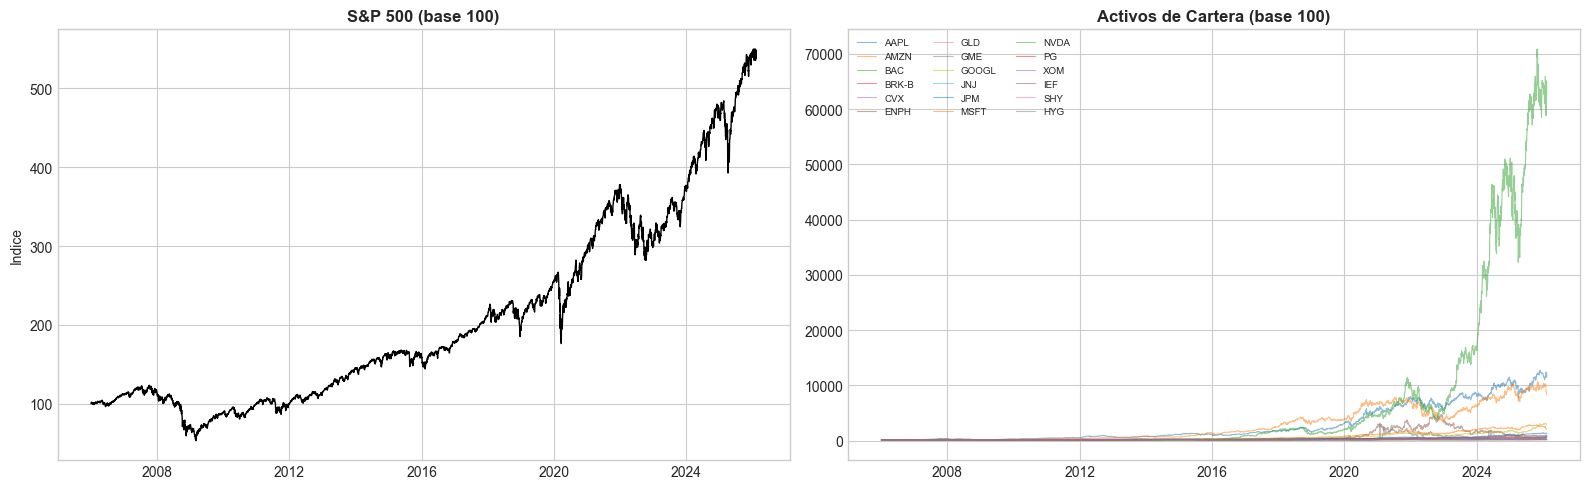

In [7]:
# Visualización rapida de precios normalizados (base 100)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: S&P 500
sp = prices[MARKET_TICKER]
axes[0].plot(sp.index, sp / sp.iloc[0] * 100, color='black', linewidth=1)
axes[0].set_title('S&P 500 (base 100)', fontweight='bold')
axes[0].set_ylabel('Indice')

# Panel derecho: todos los activos normalizados
norm = prices[TICKERS].div(prices[TICKERS].iloc[0]) * 100
for col in norm.columns:
    axes[1].plot(norm.index, norm[col], alpha=0.5, linewidth=0.8, label=col)
axes[1].set_title('Activos de Cartera (base 100)', fontweight='bold')
axes[1].legend(ncol=3, fontsize=7, loc='upper left')
plt.tight_layout()
plt.show()


### Visualización de Precios Normalizados

**(S&P 500:** Se observa la tendencia alcista a largo plazo del mercado americano, con caídas pronunciadas en los períodos de crisis (2020 COVID, 2022 estanflación) seguidas de recuperaciones. El índice ha multiplicado su valor por ~5x desde 2012.

**Activos de Cartera:** La normalización a base 100 revela la enorme dispersión de rendimientos entre activos. Destaca `NVDA`, cuya revalorización extrema (>500x) distorsiona visualmente la escala e impide apreciar el comportamiento del resto de activos. También se aprecia que los activos defensivos (`GLD`, `IEF`, `SHY`) se mantienen planos en comparación con la renta variable, confirmando su menor riesgo pero también menor rentabilidad a largo plazo.

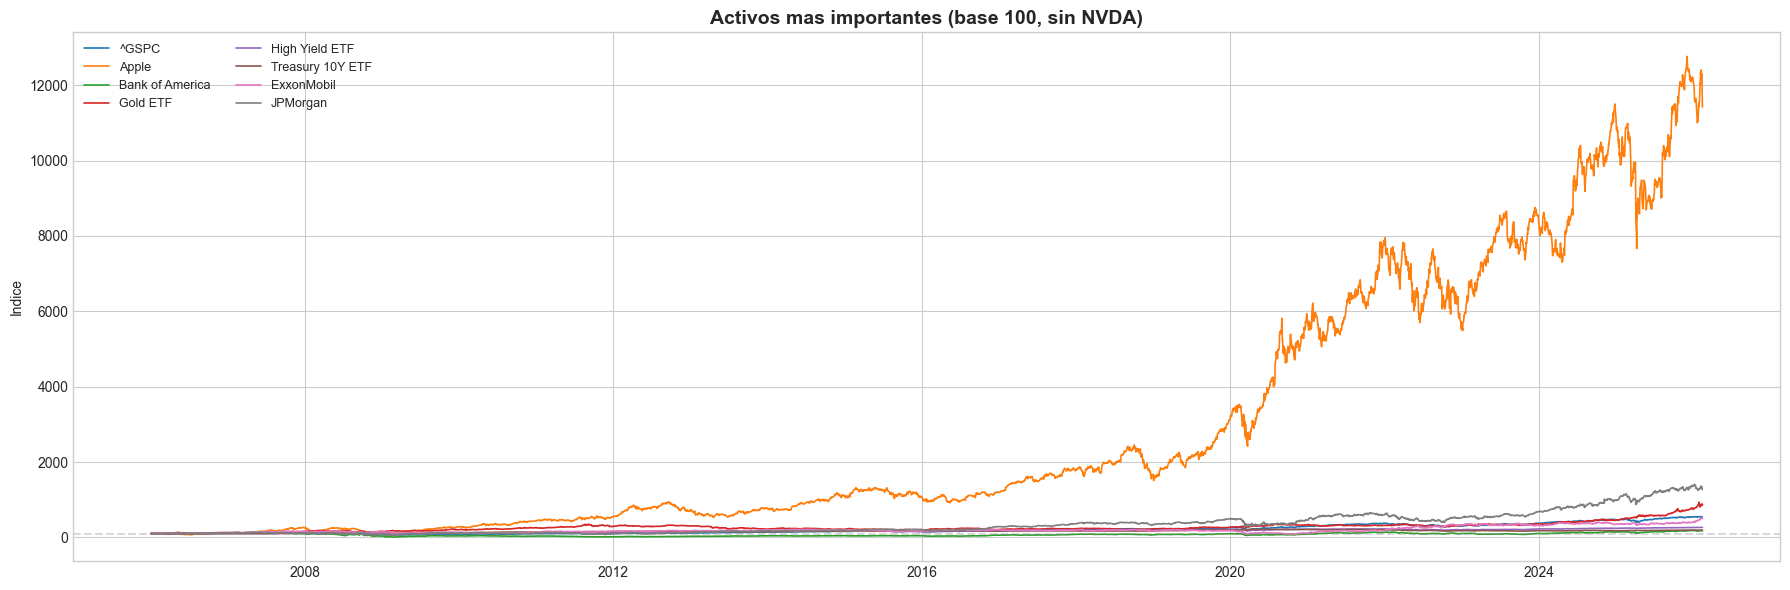

In [8]:
# Activos mas importantes (omitida NVDA para mejor escala)
importantes = ['^GSPC', 'AAPL', 'BAC', 'GLD', 'HYG', 'IEF', 'XOM', 'JPM']
norm_rep = prices[importantes].div(prices[importantes].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(18, 6))
for col in norm_rep.columns:
    label = PORTFOLIO_TICKERS.get(col, col)
    ax.plot(norm_rep.index, norm_rep[col], linewidth=1.2, label=label)

ax.set_title('Activos mas importantes (base 100, sin NVDA)', fontsize=14, fontweight='bold')
ax.set_ylabel('Indice')
ax.legend(ncol=2, fontsize=9)
ax.axhline(100, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Evolución de Activos Representativos

Al excluir NVDA de la visualización, se aprecia con mayor claridad la dinámica de cada clase de activo:

*   **Tecnología (AAPL):** Líder en rentabilidad acumulada (~15x), con caídas pronunciadas en 2020 y 2022 seguidas de recuperaciones rápidas.
*   **Banca (BAC, JPM):** Trayectorias correlaciónadas entre sí, con fuerte sensibilidad al ciclo económico. Se observa estancamiento en 2012-2016 y aceleración posterior.
*   **Energía (XOM):** Comportamiento cíclico ligado al precio del petróleo, con una década plana (2012-2020) y fuerte repunte tras la estanflación de 2022.
*   **Oro (GLD):** Crecimiento lento y estable (~2x en 14 años), con picos en períodos de incertidumbre. Baja correlación visual con el resto de activos.
*   **Bonos soberanos (IEF):** Prácticamente plano, confirmando su rol de estabilizador pero no de generador de rentabilidad. Caída visible en 2022 por las subidas de tipos.
*   **High Yield (HYG):** Estancado en torno a base 100, reflejando que su rentabilidad proviene del cupón (no del precio), con caídas en cada crisis que erosionan el capital.

Esta heterogeneidad justifica el análisis por regímenes: en calma, cada activo sigue su propia lógica; en crisis, las correlaciónes aumentan y la diversificación se debilita.

In [9]:
# Retornos logaritmicos diarios
returns = np.log(prices / prices.shift(1)).dropna()  # log(Pt/Pt-1)
print(f"Retornos: {len(returns)} observaciones")

# Resumen anualizado
summary = pd.DataFrame({
    'Media (% anual)': returns.mean() * 252 * 100,
    'Vol (% anual)': returns.std() * np.sqrt(252) * 100,
    'Skewness': returns.apply(skew),
    'Kurtosis': returns.apply(kurtosis)
}).round(2)
display(summary)


Retornos: 5060 observaciones


,Media (% anual),Vol (% anual),Skewness,Kurtosis
Ticker,,,,
AAPL,23.60,31.75,-0.22,6.54
AMZN,22.04,37.53,0.41,12.28
BAC,2.68,46.49,-0.33,26.10
BRK-B,10.59,21.30,0.39,14.60
CVX,9.47,28.54,-0.53,21.53
ENPH,9.00,68.14,-0.19,12.04
GLD,10.78,18.22,-0.45,7.07
GME,10.76,81.82,0.89,69.05
GOOGL,16.64,29.82,0.20,7.84


### Interpretación de los datos

El bloque de sanity check confirma que la base diaria es consistente: sin índices duplicados, cobertura temporal extensa (desde 2006) y trazabilidad de fuentes por bloque de riesgo. En los activos con huecos históricos se aplicó backfill económico con proxies líquidos (ENPH~XLK, HYG~LQD), preservando la información de períodos clave como 2008.

Tras la limpieza (forward fill de gaps puntuales y recorte de filas incompletas), la muestra final mantiene los principales ciclos de mercado: crisis financiera global, deuda europea, COVID-19 y estanflación 2022. Esto permite calibrar transiciones de régimen sobre un historial suficientemente heterogéneo.

La tabla de estadísticas descriptivas muestra que la mayoría de activos de riesgo presentan **kurtosis positiva** y **sesgo negativo**, alejándose de la normalidad. Este comportamiento justifica un enfoque con cambios de régimen, marginales no gaussianas y dependencia de cola.

---
## Fase 1: Detectando el "Pulso" del Mercado (Hidden Markov Models)

### Construcción del vector de features para el HMM

La detección de regímenes se modela como un problema multivariable de riesgo sistémico. La meta es identificar estados de estrés cuando varias dimensiones se deterioran de forma conjunta, evitando depender de una sola señal.

| Bloque de riesgo | Variable | Proxy operativo | Razón financiera |
| :--- | :--- | :--- | :--- |
| Mercado | `ret_mkt` | Log-return diario del S&P 500 | Resume el tono direccional agregado de renta variable |
| Volatilidad realizada | `vol21_mkt` | Std rolling 21 días del S&P 500 | Captura aceleración de riesgo observado |
| Volatilidad implicita | `dlog_vix` | Cambio logarítmico diario del VIX | Mide shocks de aversion al riesgo anticipada |
| Tipos cortos | `dy2` | Cambio diario del tramo corto (proxy 5Y/SHY) | Refleja tensión monetaria en la parte corta de la curva |
| Tipos largos | `dy10` | Cambio diario del tramo largo (10Y/IEF) | Refleja shocks de descuento y duración |
| Pendiente de curva (nivel) | `slope_10_2` | Diferencial de pendientes o proxy equivalente | Diferencia entre fases de endurecimiento y relajación |
| Crédito | `dcs` | Shock diario del spread HY vs soberano | Cuantifica ampliación de primás de riesgo de crédito |
| USD broad | `dlog_usd_broad` | Cambio logarítmico de índice USD (DXY/UUP) | Mide estrés de financiación global en dólares |
| Liquidez | `liq_factor` | Factor cross-sectional de downside y dispersion | Aproxima fricción de ejecución y venta forzada |
| Volatility Risk Premium | `vrp_proxy` | Vol implicita anualizada menos vol realizada anualizada | Captura prima de incertidumbre y precio de cobertura |

Antes del ajuste del HMM, todas las series se alinean en frecuencia diaria y se estandarizan por z-score para evitar dominancia por escala.

In [10]:
# Construir features multidimensionales para el HMM

def safe_download_close_series(ticker: str, start_date: str, end_date: str):
    """Descarga robusta de serie de cierre para un ticker (si existe)."""
    try:
        raw_dl = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
        if raw_dl is None or len(raw_dl) == 0:
            return None

        if isinstance(raw_dl.columns, pd.MultiIndex):
            if "Close" in raw_dl.columns.get_level_values(0):
                close_obj = raw_dl["Close"]
                if isinstance(close_obj, pd.DataFrame):
                    if ticker in close_obj.columns:
                        s = close_obj[ticker]
                    else:
                        s = close_obj.iloc[:, 0]
                else:
                    s = close_obj
            else:
                s = raw_dl.iloc[:, 0]
        else:
            if "Close" in raw_dl.columns:
                s = raw_dl["Close"]
            else:
                s = raw_dl.iloc[:, 0]

        s = pd.to_numeric(s, errors="coerce")
        return s
    except Exception:
        return None


hmm_features = pd.DataFrame(index=returns.index)

# 1) Mercado: retorno diario del S&P 500
hmm_features["ret_mkt"] = returns[MARKET_TICKER]

# 2) Volatilidad realizada: rolling 21 días (aprox. 1 mes habil)
hmm_features["vol21_mkt"] = returns[MARKET_TICKER].rolling(window=21, min_periods=21).std()

# 3) Tipos: dy10 y pendiente de curva en nivel (slope_10_2)
if "^TNX" in yields_df.columns:
    y10 = yields_df["^TNX"].reindex(returns.index).ffill()
    hmm_features["dy10"] = y10.diff()
else:
    y10 = None
    hmm_features["dy10"] = -returns["IEF"] * 100
    print("AVISO: Usando IEF como proxy del shock de tipos (10Y no disponible).")

if "^TNX" in yields_df.columns and "^FVX" in yields_df.columns:
    y5 = yields_df["^FVX"].reindex(returns.index).ffill()
    hmm_features["slope_10_2"] = (y10 - y5)
else:
    hmm_features["slope_10_2"] = (returns["IEF"] - returns["SHY"]).rolling(21).mean() * 100
    print("AVISO: Usando spread rolling IEF-SHY como proxy de slope_10_2.")

# 4) Credito: shock diario de spread (dcs)
spread_proxy = returns["HYG"] - returns["IEF"]
hmm_features["dcs"] = -spread_proxy * 100  # positivo = widening de spread

# 5) Liquidez: factor cross-sectional de downside y dispersion
risk_assets = [
    "AAPL", "AMZN", "BAC", "BRK-B", "CVX", "ENPH", "GME", "GOOGL", "JPM", "MSFT", "NVDA", "XOM",
]
risk_assets = [c for c in risk_assets if c in returns.columns]
if len(risk_assets) > 0:
    downside = returns[risk_assets].clip(upper=0)
    hmm_features["liq_factor"] = -downside.mean(axis=1) + downside.std(axis=1)
else:
    hmm_features["liq_factor"] = np.nan
    print("AVISO: no hay activos suficientes para calcular liq_factor.")

# 6) VIX: priorizar VIX real; si no, usar proxy
if "^VIX" in prices.columns:
    vix_series = prices["^VIX"].reindex(returns.index).ffill()
    hmm_features["dlog_vix"] = np.log(vix_series.replace(0.0, np.nan)).diff()
else:
    vix_series = safe_download_close_series("^VIX", START_DATE, END_DATE)
    if vix_series is not None and vix_series.notna().sum() > 0:
        vix_series = vix_series.reindex(returns.index).ffill()
        hmm_features["dlog_vix"] = np.log(vix_series.replace(0.0, np.nan)).diff()
        print("INFO: Usando VIX descargado directamente (^VIX).")
    else:
        vol_proxy = hmm_features["vol21_mkt"].replace(0.0, np.nan)
        hmm_features["dlog_vix"] = np.log(vol_proxy).diff()
        print("AVISO: Usando proxy de volatilidad realizada para dlog_vix (VIX no disponible).")

# 7) dy2: shock de la parte corta de tipos (o proxy)
if "^IRX" in yields_df.columns:
    y2 = yields_df["^IRX"].reindex(returns.index).ffill()
    hmm_features["dy2"] = y2.diff()
elif "^FVX" in yields_df.columns:
    y2_proxy = yields_df["^FVX"].reindex(returns.index).ffill()
    hmm_features["dy2"] = y2_proxy.diff()
    print("AVISO: Usando ^FVX como proxy de dy2 (2Y no disponible).")
elif "SHY" in returns.columns:
    hmm_features["dy2"] = returns["SHY"].diff() * 100
    print("AVISO: Usando SHY como proxy de dy2.")
else:
    hmm_features["dy2"] = np.nan
    print("AVISO: dy2 no disponible; se marca como NaN para excluirlo del ajuste.")

# 8) USD broad: cambio logaritmico diario (o proxy)
if "DTWEXBGS" in prices.columns:
    usd_series = prices["DTWEXBGS"].reindex(returns.index).ffill()
    hmm_features["dlog_usd_broad"] = np.log(usd_series.replace(0.0, np.nan)).diff()
else:
    dxy_series = None
    if "DX-Y.NYB" in prices.columns:
        dxy_series = prices["DX-Y.NYB"].reindex(returns.index).ffill()
    else:
        dxy_dl = safe_download_close_series("DX-Y.NYB", START_DATE, END_DATE)
        if dxy_dl is not None and dxy_dl.notna().sum() > 0:
            dxy_series = dxy_dl.reindex(returns.index).ffill()

    if dxy_series is not None and dxy_series.notna().sum() > 0:
        hmm_features["dlog_usd_broad"] = np.log(dxy_series.replace(0.0, np.nan)).diff()
        print("AVISO: Usando DXY (DX-Y.NYB) como proxy de USD broad.")
    else:
        uup_series = None
        if "UUP" in prices.columns:
            uup_series = prices["UUP"].reindex(returns.index).ffill()
        else:
            uup_dl = safe_download_close_series("UUP", START_DATE, END_DATE)
            if uup_dl is not None and uup_dl.notna().sum() > 0:
                uup_series = uup_dl.reindex(returns.index).ffill()

        if uup_series is not None and uup_series.notna().sum() > 0:
            hmm_features["dlog_usd_broad"] = np.log(uup_series.replace(0.0, np.nan)).diff()
            print("AVISO: Usando UUP como proxy de USD broad.")
        elif "UUP" in returns.columns:
            hmm_features["dlog_usd_broad"] = returns["UUP"]
            print("AVISO: Usando retorno de UUP como proxy de dlog_usd_broad.")
        else:
            hmm_features["dlog_usd_broad"] = np.nan
            print("AVISO: USD broad no disponible; se marca como NaN para excluirlo del ajuste.")

# 9) VRP proxy: volatilidad implicita anualizada menos volatilidad realizada anualizada
if vix_series is not None and vix_series.notna().sum() > 0:
    iv_ann = vix_series.reindex(returns.index).ffill() / 100.0
    rv_ann = hmm_features["vol21_mkt"] * np.sqrt(252)
    hmm_features["vrp_proxy"] = iv_ann - rv_ann
else:
    hmm_features["vrp_proxy"] = np.nan
    print("AVISO: VRP no disponible por falta de VIX.")

feature_order = [
    "ret_mkt",
    "vol21_mkt",
    "dlog_vix",
    "dy2",
    "dy10",
    "slope_10_2",
    "dcs",
    "dlog_usd_broad",
    "liq_factor",
    "vrp_proxy",
]
hmm_features = hmm_features[[c for c in feature_order if c in hmm_features.columns]]

# Limpiar features: primero columnas vacias, luego filas con NaN remanente
empty_cols = [c for c in hmm_features.columns if hmm_features[c].notna().sum() == 0]
if len(empty_cols) > 0:
    print(f"AVISO: Se eliminan columnas sin datos validos: {empty_cols}")
    hmm_features = hmm_features.drop(columns=empty_cols)

hmm_features = hmm_features.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Features HMM usadas ({hmm_features.shape[1]}): {list(hmm_features.columns)}")
print(f"Observaciones validas para HMM: {len(hmm_features)} dias")
display(hmm_features.describe().round(4))

INFO: Usando VIX descargado directamente (^VIX).
AVISO: Usando ^FVX como proxy de dy2 (2Y no disponible).
AVISO: Usando DXY (DX-Y.NYB) como proxy de USD broad.
Features HMM usadas (10): ['ret_mkt', 'vol21_mkt', 'dlog_vix', 'dy2', 'dy10', 'slope_10_2', 'dcs', 'dlog_usd_broad', 'liq_factor', 'vrp_proxy']
Observaciones validas para HMM: 5040 dias


,ret_mkt,vol21_mkt,dlog_vix,dy2,dy10,slope_10_2,dcs,dlog_usd_broad,liq_factor,vrp_proxy
count,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000,5040.0000
mean,0.0003,0.0101,0.0001,-0.0002,-0.0001,0.5477,-0.0059,0.0000,0.0179,0.0340
std,0.0123,0.0071,0.0767,0.0587,0.0570,0.4548,0.8318,0.0047,0.0196,0.0551
min,-0.1277,0.0022,-0.4424,-0.4580,-0.4700,-0.3600,-12.2593,-0.0272,0.0000,-0.5232
25%,-0.0041,0.0059,-0.0424,-0.0310,-0.0330,0.1630,-0.3404,-0.0026,0.0058,0.0153
50%,0.0007,0.0083,-0.0062,0.0000,-0.0010,0.4745,-0.0262,0.0000,0.0128,0.0388
75%,0.0058,0.0120,0.0347,0.0300,0.0330,0.9880,0.2979,0.0026,0.0236,0.0613
max,0.1096,0.0615,0.7682,0.4860,0.3320,1.4980,9.8292,0.0252,0.3409,0.2440


### Estadísticas Descriptivas de las Variables de Estado

La detección de regímenes se apoya en una canasta de factores con lectura económica directa y no redundante:

* **Mercado (`ret_mkt`)**: retorno diario del S&P 500 como pulso agregado de riesgo direccional.
* **Volatilidad (`vol21_mkt`, `dlog_vix`)**: combinación de riesgo realizado e implícito para capturar cambios de incertidumbre observada y anticipada.
* **Tipos (`dy2`, `dy10`, `slope_10_2`)**: shocks de curva y pendiente en nivel para reflejar tensión monetaria y de descuento.
* **Crédito (`dcs`)**: widening diario del spread HY vs soberano como indicador de deterioro de calidad crediticia.
* **Liquidez (`liq_factor`)**: tensión de ejecución aproximada por downside cross-sectional y dispersión de retornos negativos.
* **Prima de volatilidad (`vrp_proxy`)**: diferencia entre volatilidad implícita y realizada, como señal de demanda de cobertura y aversión al riesgo.
* **USD broad (`dlog_usd_broad`)**: shock de dólar amplio para capturar estrés de financiación global.

Con esta construcción, el estado de crisis se interpreta como deterioro simultáneo de volatilidad, crédito, liquidez, curva de tipos y prima de incertidumbre, en lugar de depender de una única variable.

In [11]:
# Estandarizar features antes de ajustar el HMM
# Se usa z-score para que ninguna variable domine por escala.
import contextlib
import io
import logging

def zscore_df(df: pd.DataFrame) -> pd.DataFrame:
    work = df.replace([np.inf, -np.inf], np.nan).copy()

    # Quitar columnas completamente vacias
    non_empty_cols = [c for c in work.columns if work[c].notna().sum() > 0]
    work = work[non_empty_cols]

    mu = work.mean(axis=0)
    sd = work.std(axis=0, ddof=0)

    # Si una columna no tiene varianza, se excluye del ajuste en lugar de vaciar todo X
    valid_cols = [c for c in work.columns if np.isfinite(sd[c]) and sd[c] > 0 and np.isfinite(mu[c])]
    dropped_cols = [c for c in work.columns if c not in valid_cols]
    if len(dropped_cols) > 0:
        print(f"AVISO: Columnas excluidas del HMM por varianza nula/sin datos: {dropped_cols}")

    z = (work[valid_cols] - mu[valid_cols]) / sd[valid_cols]
    z = z.replace([np.inf, -np.inf], np.nan).dropna()

    if len(z) == 0:
        raise ValueError(
            "No hay observaciones validas para el HMM tras estandarizar. "
            "Revisa factores con NaN/constantes en hmm_features."
        )

    return z


hmm_z = zscore_df(hmm_features)
X = hmm_z.values

# Modelo base (referencia) para comparar log-likelihood
def fit_base_hmm(X: np.ndarray, seed: int = SEED, covariance_type: str = "diag"):
    m = GaussianHMM(
        n_components=2,
        covariance_type=covariance_type,
        n_iter=250,
        random_state=seed,
        tol=1e-4,
        min_covar=1e-4,
    )

    hmm_logger = logging.getLogger("hmmlearn")
    prev_level = hmm_logger.level
    try:
        hmm_logger.setLevel(logging.ERROR)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            m.fit(X)
    finally:
        hmm_logger.setLevel(prev_level)

    return m, float(m.score(X))


# Modelo robusto con persistencia (sticky) y múltiples reinicios
# Nota: se mantiene SIEMPRE n_components=2 (Calma/Crisis).
def fit_sticky_hmm(
    X: np.ndarray,
    n_components: int = 2,
    n_inits: int = 10,
    diag_strength: float = 4000.0,
    off_strength: float = 1.0,
    init_self_p: float = 0.992,
    n_iter: int = 600,
    tol: float = 1e-4,
    min_covar: float = 1e-4,
    base_seed: int = 100,
    covariance_type: str = "diag",
):
    if n_components != 2:
        raise ValueError("Este notebook fija n_components=2 por diseno (calma/crisis).")

    best = {"ll": -np.inf, "model": None}

    transmat_prior = np.full((n_components, n_components), off_strength, dtype=float)
    np.fill_diagonal(transmat_prior, diag_strength)

    trans0 = np.full((n_components, n_components), (1.0 - init_self_p) / (n_components - 1), dtype=float)
    np.fill_diagonal(trans0, init_self_p)
    start0 = np.full(n_components, 1.0 / n_components, dtype=float)

    for k in range(n_inits):
        seed = base_seed + k
        m = GaussianHMM(
            n_components=n_components,
            covariance_type=covariance_type,
            n_iter=n_iter,
            tol=tol,
            random_state=seed,
            algorithm="map",
            min_covar=min_covar,
            transmat_prior=transmat_prior,
        )

        m.init_params = "mc"   # inicializa solo medias/covarianzas
        m.params = "stmc"      # reestima todo con prior de transición
        m.startprob_ = start0.copy()
        m.transmat_ = trans0.copy()

        hmm_logger = logging.getLogger("hmmlearn")
        prev_level = hmm_logger.level
        try:
            hmm_logger.setLevel(logging.ERROR)
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                m.fit(X)
        finally:
            hmm_logger.setLevel(prev_level)

        ll = float(m.score(X))
        if ll > best["ll"]:
            best = {"ll": ll, "model": m}

    return best["model"], best["ll"]


base_model, ll_base = fit_base_hmm(X, covariance_type="diag")
model, ll_sticky = fit_sticky_hmm(X, covariance_type="diag")

raw_states = model.predict(X)
p_states = model.predict_proba(X)

print("HMM ajustado con configuración robusta (sticky + multi-start, 2 estados).")
print(f"LogLik base={ll_base:,.1f} | LogLik sticky(diag)={ll_sticky:,.1f}")
print(f"Estado 0: {(raw_states == 0).sum()} días | Estado 1: {(raw_states == 1).sum()} dias")

HMM ajustado con configuración robusta (sticky + multi-start, 2 estados).
LogLik base=-60,921.5 | LogLik sticky(diag)=-61,256.9
Estado 0: 3591 días | Estado 1: 1449 dias


El HMM se estima con una configuración robusta (persistencia en transiciones + múltiples reinicios), lo que reduce cambios espurios y mejora estabilidad temporal.

La asignación final de etiquetas se realiza con un **score económico de estrés** que combina bloques de volatilidad (`vol21_mkt`, `dlog_vix`, `vrp_proxy`), crédito (`dcs`), liquidez (`liq_factor`), tipos (`dy2`, `dy10`, `slope_10_2`) y dólar (`dlog_usd_broad`). Así, la etiqueta "Crisis" representa un deterioro financiero interpretable y no solo una clase numérica del algoritmo.

In [12]:
# Identificar estado de crisis con score económico (no solo por volatilidad)
def wmean(x: np.ndarray, w: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    m = np.isfinite(x) & np.isfinite(w)
    if m.sum() == 0:
        return np.nan
    ww = w[m]
    den = ww.sum()
    if den <= 0:
        return np.nan
    return float(np.sum(x[m] * ww) / den)


def state_signal_mu(df: pd.DataFrame, col: str, w: np.ndarray) -> float:
    if col not in df.columns:
        return np.nan
    return wmean(df[col].values, w)


state_scores = []
state_components = []
for k in range(2):
    wk = p_states[:, k]

    vol_mu = state_signal_mu(hmm_features, "vol21_mkt", wk)
    credit_mu = state_signal_mu(hmm_features, "dcs", wk)
    liq_mu = state_signal_mu(hmm_features, "liq_factor", wk)

    dy2_mu = state_signal_mu(hmm_features, "dy2", wk)
    dy10_mu = state_signal_mu(hmm_features, "dy10", wk)
    slope_mu = state_signal_mu(hmm_features, "slope_10_2", wk)

    vix_mu = state_signal_mu(hmm_features, "dlog_vix", wk)
    usd_mu = state_signal_mu(hmm_features, "dlog_usd_broad", wk)
    vrp_mu = state_signal_mu(hmm_features, "vrp_proxy", wk)

    # En estrés esperamos valores altos para volatilidad/crédito/liquidez/VIX/USD/VRP
    vol_score = max(vol_mu, 0.0) if np.isfinite(vol_mu) else 0.0
    credit_score = max(credit_mu, 0.0) if np.isfinite(credit_mu) else 0.0
    liq_score = max(liq_mu, 0.0) if np.isfinite(liq_mu) else 0.0
    vix_score = max(vix_mu, 0.0) if np.isfinite(vix_mu) else 0.0
    usd_score = max(usd_mu, 0.0) if np.isfinite(usd_mu) else 0.0
    vrp_score = max(vrp_mu, 0.0) if np.isfinite(vrp_mu) else 0.0

    # En tipos usamos magnitud absoluta de shocks y pendiente
    rates_score = 0.0
    if np.isfinite(dy2_mu):
        rates_score += abs(dy2_mu)
    if np.isfinite(dy10_mu):
        rates_score += abs(dy10_mu)
    if np.isfinite(slope_mu):
        rates_score += abs(slope_mu)

    total_score = (
        vol_score
        + credit_score
        + liq_score
        + 0.75 * rates_score
        + 0.50 * vix_score
        + 0.30 * usd_score
        + 0.35 * vrp_score
    )

    state_scores.append(total_score)
    state_components.append(
        {
            "state": k,
            "vol": vol_score,
            "credit": credit_score,
            "liq": liq_score,
            "rates": rates_score,
            "vix": vix_score,
            "usd": usd_score,
            "vrp": vrp_score,
            "total": total_score,
        }
    )

stress_state = int(np.argmax(state_scores))

# Reordenar para mantener convencion: 0=Calma, 1=Crisis
if stress_state == 0:
    raw_states = 1 - raw_states
    p_states = p_states[:, ::-1]
    model.means_ = model.means_[::-1]
    model.covars_ = model.covars_[::-1]
    model.transmat_ = model.transmat_[::-1, ::-1]
    model.startprob_ = model.startprob_[::-1]

# Probabilidad diaria de crisis (señal "soft")
p_stress = p_states[:, 1]

print("Asignacion final: Estado 0 = Calma | Estado 1 = Crisis")
print("Score ponderado = base + 0.75*rates + 0.50*VIX + 0.30*USD + 0.35*VRP")
print(f"Score estado 0: {state_scores[1 if stress_state == 0 else 0]:.4f}")
print(f"Score estado 1: {state_scores[stress_state]:.4f}")
print(f"Vol media calma:  {hmm_features['vol21_mkt'].values[raw_states == 0].mean():.4f}")
print(f"Vol media crisis: {hmm_features['vol21_mkt'].values[raw_states == 1].mean():.4f}")
print(f"p_stress media: {np.mean(p_stress):.3f}")
display(pd.DataFrame(state_components).set_index("state").round(4))

Asignacion final: Estado 0 = Calma | Estado 1 = Crisis
Score ponderado = base + 0.75*rates + 0.50*VIX + 0.30*USD + 0.35*VRP
Score estado 0: 0.4419
Score estado 1: 0.5753
Vol media calma:  0.0073
Vol media crisis: 0.0172
p_stress media: 0.289


,vol,credit,liq,rates,vix,usd,vrp,total
state,,,,,,,,
0,0.0073,0.0000,0.0136,0.5408,0.0000,0.0000,0.0439,0.4419
1,0.0172,0.0838,0.0286,0.5824,0.0111,0.0002,0.0095,0.5753


In [13]:
# Filtrado robusto de episodios: histéresis + fusión de gaps + duración minima
MIN_CRISIS_DAYS = 50
ENTER_THR = 0.85
EXIT_THR = 0.35
MAX_GAP_DAYS = 15


def hysteresis_binary(p: np.ndarray, enter_thr: float = 0.7, exit_thr: float = 0.3) -> np.ndarray:
    p = np.asarray(p, dtype=float)
    y = np.zeros_like(p, dtype=int)
    in_stress = False
    for t, pt in enumerate(p):
        if not in_stress and pt >= enter_thr:
            in_stress = True
        elif in_stress and pt <= exit_thr:
            in_stress = False
        y[t] = 1 if in_stress else 0
    return y


def remove_short_runs(binary: np.ndarray, min_len: int) -> np.ndarray:
    x = np.asarray(binary, dtype=int)
    if len(x) == 0:
        return x
    change = np.r_[True, x[1:] != x[:-1]]
    starts = np.where(change)[0]
    ends = np.r_[starts[1:] - 1, len(x) - 1]
    out = x.copy()
    for a, b in zip(starts, ends):
        if x[a] == 1 and (b - a + 1) < min_len:
            out[a:b + 1] = 0
    return out


def merge_close_runs_once(binary: np.ndarray, max_gap: int) -> np.ndarray:
    x = np.asarray(binary, dtype=int)
    if len(x) == 0:
        return x
    change = np.r_[True, x[1:] != x[:-1]]
    starts = np.where(change)[0]
    ends = np.r_[starts[1:] - 1, len(x) - 1]
    out = x.copy()

    for i in range(len(starts) - 2):
        a1, b1 = starts[i], ends[i]
        a0, b0 = starts[i + 1], ends[i + 1]
        a2, b2 = starts[i + 2], ends[i + 2]
        if x[a1] == 1 and x[a0] == 0 and x[a2] == 1 and (b0 - a0 + 1) <= max_gap:
            out[a0:b0 + 1] = 1
    return out


def merge_close_runs(binary: np.ndarray, max_gap: int, max_iters: int = 10) -> np.ndarray:
    out = np.asarray(binary, dtype=int)
    for _ in range(max_iters):
        new = merge_close_runs_once(out, max_gap=max_gap)
        if np.array_equal(new, out):
            break
        out = new
    return out


def state_runs(states_arr: np.ndarray, dates: pd.DatetimeIndex) -> pd.DataFrame:
    s = np.asarray(states_arr, dtype=int)
    if len(s) != len(dates):
        raise ValueError("states y dates deben tener la misma longitud")
    if len(s) == 0:
        return pd.DataFrame(columns=["state", "start", "end", "n_days"])

    change = np.r_[True, s[1:] != s[:-1]]
    starts = np.where(change)[0]
    ends = np.r_[starts[1:] - 1, len(s) - 1]

    rows = []
    for a, b in zip(starts, ends):
        rows.append({
            "state": int(s[a]),
            "start": dates[a],
            "end": dates[b],
            "n_days": int(b - a + 1),
        })
    return pd.DataFrame(rows)


# Pipeline de crisis financiero-económicamente interpretable
raw_stress = hysteresis_binary(p_stress, enter_thr=ENTER_THR, exit_thr=EXIT_THR)
stress_merged = merge_close_runs(raw_stress, max_gap=MAX_GAP_DAYS)
states = remove_short_runs(stress_merged, min_len=MIN_CRISIS_DAYS)

n_filtered = int((raw_states != states).sum())
print(f"Filtro aplicado: {n_filtered} días reclasificados respecto a Viterbi bruto")
print(f"Parametros: enter={ENTER_THR:.2f}, exit={EXIT_THR:.2f}, min_len={MIN_CRISIS_DAYS}, max_gap={MAX_GAP_DAYS}")
print(f"Final: Calma={(states == 0).sum()} días ({(states == 0).mean():.1%}) | Crisis={(states == 1).sum()} días ({(states == 1).mean():.1%})")

Filtro aplicado: 639 días reclasificados respecto a Viterbi bruto
Parametros: enter=0.85, exit=0.35, min_len=50, max_gap=15
Final: Calma=3508 días (69.6%) | Crisis=1532 días (30.4%)


In [14]:
# Alinear estados con retornos (mismo rango temporal)
returns = returns.loc[hmm_features.index].copy()
returns["State"] = states
returns["p_stress"] = p_stress


def estimate_transmat(states_arr: np.ndarray, alpha: float = 1.0) -> tuple[np.ndarray, np.ndarray]:
    """Matriz de transición empirica con suavizado de Laplace."""
    s = np.asarray(states_arr, dtype=int)
    counts = np.full((2, 2), alpha, dtype=float)
    for t in range(1, len(s)):
        counts[s[t - 1], s[t]] += 1
    probs = counts / counts.sum(axis=1, keepdims=True)
    return probs, counts


transmat_emp, trans_counts = estimate_transmat(states, alpha=1.0)
TRANSMAT_SIM = transmat_emp.copy()  # matriz usada por el motor de simulación

trans_df = pd.DataFrame(
    TRANSMAT_SIM,
    index=["Desde Calma", "Desde Crisis"],
    columns=["Hacia Calma", "Hacia Crisis"],
)
display(trans_df.round(4))

# Duraciones esperadas por estado segun la matriz final usada en simulación
dur_calma = 1.0 / max(1e-12, TRANSMAT_SIM[0, 1])
dur_crisis = 1.0 / max(1e-12, TRANSMAT_SIM[1, 0])
print(f"Duracion esperada: Calma ~{dur_calma:.0f} días | Crisis ~{dur_crisis:.0f} dias")
print("(Matriz estimada sobre estados filtrados para mantener coherencia financiera.)")

,Hacia Calma,Hacia Crisis
Desde Calma,0.9966,0.0034
Desde Crisis,0.0078,0.9922


Duracion esperada: Calma ~292 días | Crisis ~128 dias
(Matriz estimada sobre estados filtrados para mantener coherencia financiera.)


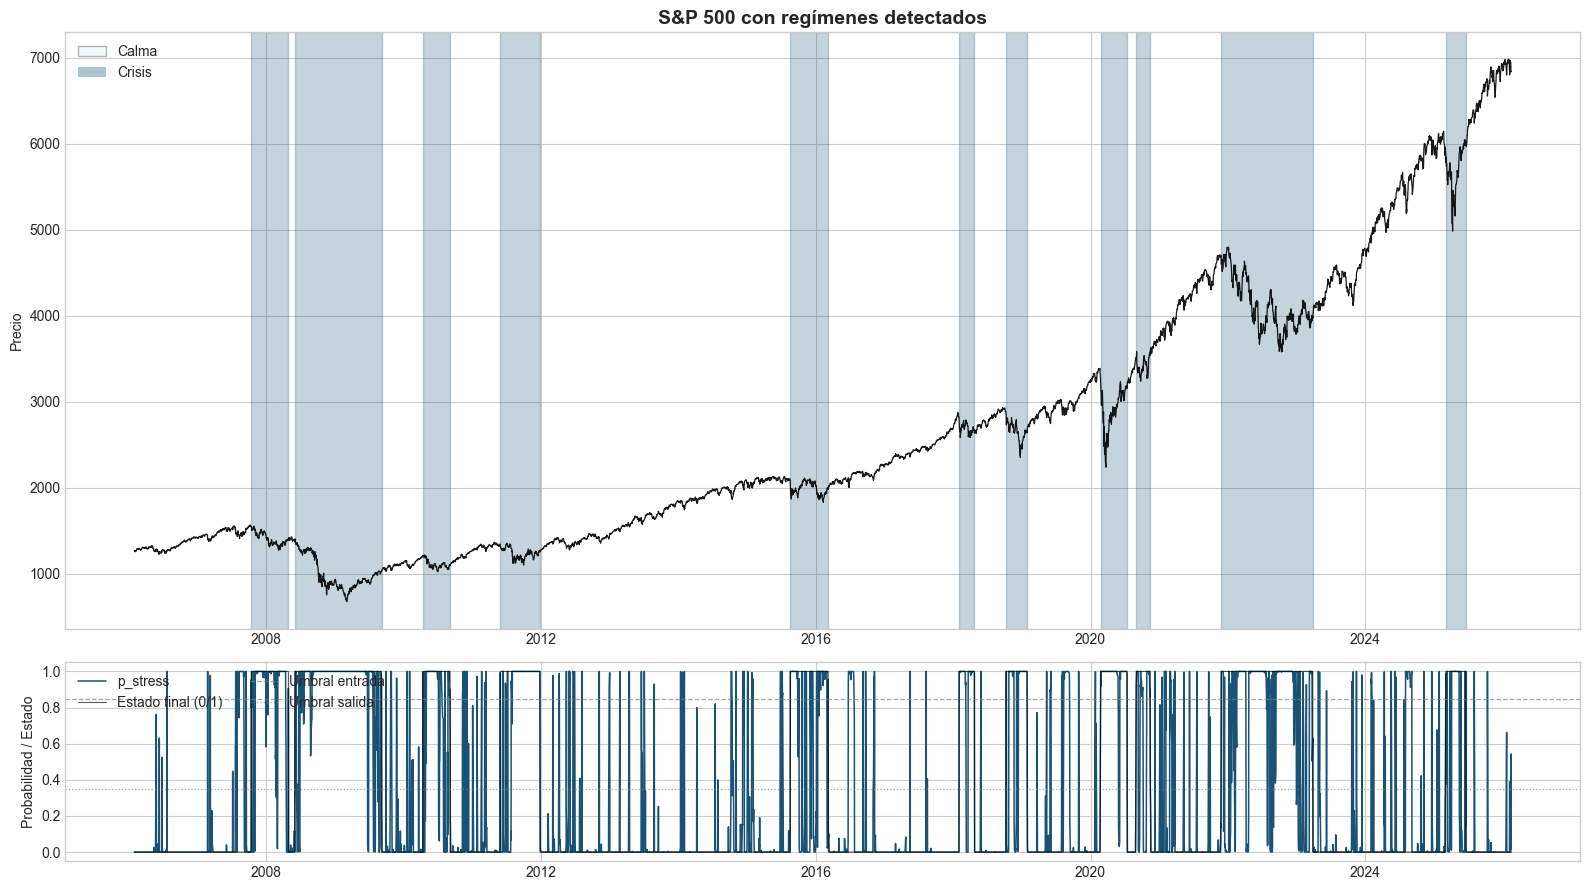

In [15]:
# Grafico de regímenes (enunciado: Blanco=Calma, Azul=Crisis)
price_data = prices[MARKET_TICKER].loc[returns.index]
runs_df = state_runs(states, price_data.index)
periods_stress = runs_df[runs_df["state"] == 1].copy().reset_index(drop=True)
periods_stress["period_id"] = np.arange(1, len(periods_stress) + 1)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={"height_ratios": [3, 1]})

# Panel 1: S&P500 + sombreado de episodios de crisis
ax1 = axes[0]
ax1.plot(price_data.index, price_data.values, color="black", linewidth=0.9, alpha=0.9)
for _, r in periods_stress.iterrows():
    ax1.axvspan(r["start"], r["end"], color=COLOR_CRISIS, alpha=0.25)

ax1.set_title("S&P 500 con regímenes detectados", fontsize=14, fontweight="bold")
ax1.set_ylabel("Precio")
ax1.legend(handles=[
    Patch(facecolor=COLOR_CALMA_FILL, edgecolor="gray", alpha=0.6, label="Calma"),
    Patch(facecolor=COLOR_CRISIS, alpha=0.35, label="Crisis"),
], loc="upper left")

# Panel 2: probabilidad diaria de crisis + estado final binario
ax2 = axes[1]
ax2.plot(price_data.index, p_stress, color=COLOR_CRISIS, linewidth=1.1, label="p_stress")
ax2.plot(price_data.index, states, color="black", linewidth=0.8, alpha=0.65, label="Estado final (0/1)")
ax2.axhline(ENTER_THR, color="gray", linestyle="--", linewidth=0.9, alpha=0.7, label="Umbral entrada")
ax2.axhline(EXIT_THR, color="gray", linestyle=":", linewidth=0.9, alpha=0.7, label="Umbral salida")
ax2.set_ylim(-0.05, 1.05)
ax2.set_ylabel("Probabilidad / Estado")
ax2.legend(loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

### Visualización de Régimenes Detectados

El gráfico superpone episodios de crisis (bandas azules) sobre la serie del S&P 500 y, en el panel inferior, la probabilidad diaria de estrés (`p_stress`) junto con el estado binario final.

**Lectura financiera:**
* **Coherencia temporal:** los episodios agregan días contiguos y evitan cambios de estado espurios de 1-2 días.
* **Transiciones interpretables:** la entrada/salida de crisis queda gobernada por umbrales asimétricos (histéresis), reproduciendo la inercia real de mercado.
* **Consistencia financiera:** los episodios de estrés coinciden con ampliación de spread de crédito, deterioro de liquidez, tensión en curva de tipos y repuntes conjuntos de VIX/VRP.

### Benchmark técnico del HMM (2 estados): `diag` vs `full`

En esta etapa la cuestión principal ya no es si el modelo identifica regímenes, sino qué especificación resulta metodológicamente más sólida. Por ello se comparan las dos estructuras de covarianza (`diag` y `full`) manteniendo constantes el resto de componentes del pipeline: etiquetado económico, postfiltro y criterios de lectura.

La evaluación se plantea en dos dimensiones complementarias. En la dimensión estadística se revisan `log_likelihood`, AIC y BIC, incorporando la penalización por complejidad para controlar el riesgo de sobreajuste. En la dimensión financiera se analizan la proporción de días en crisis, la estructura de episodios (número y duración) y el spread de volatilidad anualizada crisis-calma, que sintetiza la capacidad de discriminación económica del detector.

Dado que los estados del HMM son intercambiables, se reetiquetan con un criterio económico para asegurar una interpretación estable del estado de estrés. La recomendación final de covarianza se adopta solo cuando existe mejora estadística sin deterioro de la coherencia financiera de la clasificación.

In [16]:
# Benchmark tecnico (2 estados): covariance_type="diag" vs "full"
# Se usa el mismo pipeline de etiquetado económico y postfiltro para comparar de forma consistente.

def economic_scores_from_probs(features_df: pd.DataFrame, probs: np.ndarray) -> list:
    scores = []
    for k in range(2):
        wk = probs[:, k]

        vol_mu = state_signal_mu(features_df, "vol21_mkt", wk)
        credit_mu = state_signal_mu(features_df, "dcs", wk)
        liq_mu = state_signal_mu(features_df, "liq_factor", wk)

        dy2_mu = state_signal_mu(features_df, "dy2", wk)
        dy10_mu = state_signal_mu(features_df, "dy10", wk)
        slope_mu = state_signal_mu(features_df, "slope_10_2", wk)

        vix_mu = state_signal_mu(features_df, "dlog_vix", wk)
        usd_mu = state_signal_mu(features_df, "dlog_usd_broad", wk)
        vrp_mu = state_signal_mu(features_df, "vrp_proxy", wk)

        vol_score = max(vol_mu, 0.0) if np.isfinite(vol_mu) else 0.0
        credit_score = max(credit_mu, 0.0) if np.isfinite(credit_mu) else 0.0
        liq_score = max(liq_mu, 0.0) if np.isfinite(liq_mu) else 0.0
        vix_score = max(vix_mu, 0.0) if np.isfinite(vix_mu) else 0.0
        usd_score = max(usd_mu, 0.0) if np.isfinite(usd_mu) else 0.0
        vrp_score = max(vrp_mu, 0.0) if np.isfinite(vrp_mu) else 0.0

        rates_score = 0.0
        if np.isfinite(dy2_mu):
            rates_score += abs(dy2_mu)
        if np.isfinite(dy10_mu):
            rates_score += abs(dy10_mu)
        if np.isfinite(slope_mu):
            rates_score += abs(slope_mu)

        total_score = (
            vol_score
            + credit_score
            + liq_score
            + 0.75 * rates_score
            + 0.50 * vix_score
            + 0.30 * usd_score
            + 0.35 * vrp_score
        )
        scores.append(total_score)
    return scores


def postfilter_states_binary(
    p_stress_arr: np.ndarray,
    enter_thr: float,
    exit_thr: float,
    min_len: int,
    max_gap: int,
) -> np.ndarray:
    raw = hysteresis_binary(p_stress_arr, enter_thr=enter_thr, exit_thr=exit_thr)
    merged = merge_close_runs(raw, max_gap=max_gap)
    return remove_short_runs(merged, min_len=min_len)


def hmm_param_count(n_features: int, covariance_type: str, n_components: int = 2) -> int:
    # Aproximacion para AIC/BIC del HMM gaussiano (2 estados fijos)
    startprob_params = n_components - 1
    transmat_params = n_components * (n_components - 1)
    mean_params = n_components * n_features
    if covariance_type == "diag":
        cov_params = n_components * n_features
    else:
        cov_params = n_components * (n_features * (n_features + 1) // 2)
    return int(startprob_params + transmat_params + mean_params + cov_params)


import contextlib
import io
import logging


def fit_sticky_hmm_silent(*args, **kwargs):
    # Silencia avisos de no convergencia para limpiar la salida del notebook.
    hmm_logger = logging.getLogger("hmmlearn")
    prev_level = hmm_logger.level
    try:
        hmm_logger.setLevel(logging.ERROR)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            return fit_sticky_hmm(*args, **kwargs)
    finally:
        hmm_logger.setLevel(prev_level)


returns_bench = returns.loc[hmm_features.index].copy()
benchmark_rows = []
benchmark_states = {}
benchmark_p_stress = {}

for cov_type in ["diag", "full"]:
    cov_model, cov_ll = fit_sticky_hmm_silent(X, covariance_type=cov_type)

    cov_raw_states = cov_model.predict(X)
    cov_p_states = cov_model.predict_proba(X)

    cov_scores = economic_scores_from_probs(hmm_features, cov_p_states)
    cov_stress_state = int(np.argmax(cov_scores))

    if cov_stress_state == 0:
        cov_raw_states = 1 - cov_raw_states
        cov_p_states = cov_p_states[:, ::-1]

    cov_p_stress = cov_p_states[:, 1]
    cov_states = postfilter_states_binary(
        cov_p_stress,
        enter_thr=ENTER_THR,
        exit_thr=EXIT_THR,
        min_len=MIN_CRISIS_DAYS,
        max_gap=MAX_GAP_DAYS,
    )

    benchmark_states[cov_type] = cov_states
    benchmark_p_stress[cov_type] = cov_p_stress

    runs_cov = state_runs(cov_states, hmm_features.index)
    crisis_runs_cov = runs_cov.loc[runs_cov["state"] == 1, "n_days"]

    mask_crisis = cov_states == 1
    mask_calma = cov_states == 0

    vol_crisis = np.nan
    vol_calma = np.nan
    if mask_crisis.sum() > 2:
        vol_crisis = float(returns_bench.loc[mask_crisis, MARKET_TICKER].std() * np.sqrt(252) * 100)
    if mask_calma.sum() > 2:
        vol_calma = float(returns_bench.loc[mask_calma, MARKET_TICKER].std() * np.sqrt(252) * 100)

    n_params = hmm_param_count(X.shape[1], cov_type, n_components=2)
    n_obs = max(len(X), 1)
    aic = 2 * n_params - 2 * cov_ll
    bic = np.log(n_obs) * n_params - 2 * cov_ll

    benchmark_rows.append(
        {
            "covariance_type": cov_type,
            "log_likelihood": cov_ll,
            "AIC": aic,
            "BIC": bic,
            "% días crisis": float(mask_crisis.mean() * 100),
            "n episodios crisis": int((runs_cov["state"] == 1).sum()),
            "duración media crisis (días)": float(crisis_runs_cov.mean()) if len(crisis_runs_cov) else np.nan,
            "vol crisis anualizada (%)": vol_crisis,
            "vol calma anualizada (%)": vol_calma,
            "spread vol crisis-calma": float(vol_crisis - vol_calma) if (np.isfinite(vol_crisis) and np.isfinite(vol_calma)) else np.nan,
        }
    )

benchmark_table = pd.DataFrame(benchmark_rows).set_index("covariance_type").round(3)

recommended_covariance = "diag"
if (
    benchmark_table.loc["full", "BIC"] < benchmark_table.loc["diag", "BIC"]
    and benchmark_table.loc["full", "spread vol crisis-calma"] >= benchmark_table.loc["diag", "spread vol crisis-calma"]
):
    recommended_covariance = "full"

print("BENCHMARK 2 ESTADOS: DIAG VS FULL")
display(benchmark_table)
print(f"Covarianza recomendada (2 estados): {recommended_covariance}")

BENCHMARK 2 ESTADOS: DIAG VS FULL


,log_likelihood,AIC,BIC,% días crisis,n episodios crisis,duración media crisis (días),vol crisis anualizada (%),vol calma anualizada (%),spread vol crisis-calma
covariance_type,,,,,,,,,
diag,-61256.875,122599.750,122880.332,30.397,11,139.273,30.715,11.580,19.135
full,-47976.594,96219.188,97087.035,26.111,10,131.600,32.249,12.143,20.105


Covarianza recomendada (2 estados): full


### Validación walk-forward sin fuga temporal

Una vez selecciónada la covarianza, el siguiente paso es verificar la estabilidad del detector en un entorno temporal realista. El esquema walk-forward reproduce esa lógica: entrenar con información histórica disponible y evaluar en un bloque futuro no observado durante el ajuste.

La validez del ejercicio descansa en evitar fuga de información. Por ello, la estandarización se calcula exclusivamente en train y se aplica después a test; adicionalmente, la identificación del estado de estrés se determina en train y se proyecta a test antes de ejecutar el postfiltro.

La tabla por ventanas debe interpretarse como evidencia de robustez dinámica: persistencia de la separación crisis-calma, estructura temporal de episodios y consistencia en la volatilidad relativa entre regímenes. Si ese patrón se mantiene, el resultado trasciende el ajuste in-sample y se aproxima a una herramienta operativa de seguimiento del riesgo.

Con la covarianza ya elegida, aquí damos un paso natural: comprobar si el detector sigue siendo útil cuando el tiempo avanza. La idea del walk-forward es entrenar con pasado, congelar el modelo y exigirle que clasifique un bloque futuro que no ha visto nunca.

Para que la prueba sea limpia, la estandarización se calcula solo con el tramo de entrenamiento y luego se aplica a test. Ese detalle evita leakage. Del mismo modo, el estado que interpretamos como estrés se identifica en train y se traslada a test antes del postfiltro (histéresis, mínimos de duración y cierre de huecos).

La salida por ventanas se lee como una historia temporal del detector: si mantiene separación crisis-calma, si los episodios conservan estructura y si la volatilidad en crisis permanece sistemáticamente distinta. Cuando ese patrón aparece de forma repetida, la metodología deja de ser una buena foto in-sample y pasa a ser una herramienta robusta de seguimiento de riesgo.

In [17]:
# Validación walk-forward (sin fuga temporal) del detector de estados (2 estados)
import contextlib
import io
import logging


def fit_sticky_hmm_silent(*args, **kwargs):
    # Silencia avisos de no convergencia para limpiar la salida del notebook.
    hmm_logger = logging.getLogger("hmmlearn")
    prev_level = hmm_logger.level
    try:
        hmm_logger.setLevel(logging.ERROR)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            return fit_sticky_hmm(*args, **kwargs)
    finally:
        hmm_logger.setLevel(prev_level)


def walk_forward_detection(
    features_df: pd.DataFrame,
    returns_df: pd.DataFrame,
    train_window: int = 252 * 4,
    test_window: int = 126,
    step_size: int = 63,
    covariance_type: str = "diag",
):
    records = []
    wf_states_all = pd.Series(index=features_df.index, dtype=float)
    wf_p_stress_all = pd.Series(index=features_df.index, dtype=float)

    n_total = len(features_df)
    last_start = n_total - train_window - test_window
    if last_start <= 0:
        return pd.DataFrame(), wf_states_all, wf_p_stress_all

    for start in range(0, last_start + 1, step_size):
        train_slice = slice(start, start + train_window)
        test_slice = slice(start + train_window, start + train_window + test_window)

        train_df = features_df.iloc[train_slice].copy()
        test_df = features_df.iloc[test_slice].copy()
        if len(test_df) == 0:
            continue

        # Estandarizacion estricta con estadisticos de train (evita leakage)
        mu = train_df.mean(axis=0)
        sd = train_df.std(axis=0, ddof=0).replace(0.0, 1.0)

        train_z = ((train_df - mu) / sd).replace([np.inf, -np.inf], np.nan).dropna()
        test_z = ((test_df - mu) / sd).replace([np.inf, -np.inf], np.nan).dropna()

        if len(train_z) < 100 or len(test_z) < 20:
            continue

        wf_model, wf_ll = fit_sticky_hmm_silent(train_z.values, covariance_type=covariance_type)

        # Etiquetado económico aprendido en train
        p_train = wf_model.predict_proba(train_z.values)
        train_scores = economic_scores_from_probs(train_df.loc[train_z.index], p_train)
        stress_state_train = int(np.argmax(train_scores))

        # Prediccion en test con modelo fijo
        raw_test = wf_model.predict(test_z.values)
        p_test = wf_model.predict_proba(test_z.values)

        if stress_state_train == 0:
            raw_test = 1 - raw_test
            p_test = p_test[:, ::-1]

        p_stress_test = p_test[:, 1]
        states_test = postfilter_states_binary(
            p_stress_test,
            enter_thr=ENTER_THR,
            exit_thr=EXIT_THR,
            min_len=MIN_CRISIS_DAYS,
            max_gap=MAX_GAP_DAYS,
        )

        test_idx = test_z.index
        wf_states_all.loc[test_idx] = states_test
        wf_p_stress_all.loc[test_idx] = p_stress_test

        runs_test = state_runs(states_test, test_idx)
        crisis_runs = runs_test.loc[runs_test["state"] == 1, "n_days"]

        mask_crisis = states_test == 1
        mask_calma = states_test == 0

        vol_crisis = np.nan
        vol_calma = np.nan
        if mask_crisis.sum() > 2:
            vol_crisis = float(returns_df.loc[test_idx[mask_crisis], MARKET_TICKER].std() * np.sqrt(252) * 100)
        if mask_calma.sum() > 2:
            vol_calma = float(returns_df.loc[test_idx[mask_calma], MARKET_TICKER].std() * np.sqrt(252) * 100)

        records.append(
            {
                "train_start": train_z.index[0],
                "train_end": train_z.index[-1],
                "test_start": test_idx[0],
                "test_end": test_idx[-1],
                "covariance_type": covariance_type,
                "train_loglik": float(wf_ll),
                "pct_crisis": float(mask_crisis.mean() * 100),
                "n_crisis_days": int(mask_crisis.sum()),
                "n_episodios_crisis": int((runs_test["state"] == 1).sum()),
                "duración_media_crisis": float(crisis_runs.mean()) if len(crisis_runs) else np.nan,
                "vol_crisis_ann": vol_crisis,
                "vol_calma_ann": vol_calma,
            }
        )

    return pd.DataFrame(records), wf_states_all, wf_p_stress_all


returns_wf = returns.loc[hmm_features.index].copy()
wf_results, wf_states_all, wf_p_stress_all = walk_forward_detection(
    hmm_features,
    returns_wf,
    train_window=252 * 4,
    test_window=126,
    step_size=63,
    covariance_type=recommended_covariance,
)

print("VALIDACION WALK-FORWARD (2 estados)")
if len(wf_results) == 0:
    print("No se pudieron construir ventanas suficientes con la configuración actual.")
else:
    display(wf_results.round(3))
    wf_summary = pd.DataFrame(
        {
            "Metrica": [
                "Numero de ventanas",
                "% crisis medio",
                "Std % crisis",
                "Vol crisis media ann",
                "Vol calma media ann",
            ],
            "Valor": [
                int(len(wf_results)),
                float(wf_results["pct_crisis"].mean()),
                float(wf_results["pct_crisis"].std(ddof=0)),
                float(wf_results["vol_crisis_ann"].mean()),
                float(wf_results["vol_calma_ann"].mean()),
            ],
        }
    )
    display(wf_summary.round(3))

VALIDACION WALK-FORWARD (2 estados)


,train_start,train_end,test_start,test_end,covariance_type,train_loglik,pct_crisis,n_crisis_days,n_episodios_crisis,duración_media_crisis,vol_crisis_ann,vol_calma_ann
0,2006-02-02,2010-02-03,2010-02-04,2010-08-04,full,-8426.906,0.000,0,0,NaN,NaN,21.073
1,2006-05-04,2010-05-05,2010-05-06,2010-11-02,full,-8591.300,0.000,0,0,NaN,NaN,21.259
2,2006-08-03,2010-08-04,2010-08-05,2011-02-02,full,-8703.578,0.000,0,0,NaN,NaN,13.539
3,2006-11-01,2010-11-02,2010-11-03,2011-05-04,full,-8817.910,0.000,0,0,NaN,NaN,12.182
4,2007-02-05,2011-02-02,2011-02-03,2011-08-03,full,-8912.053,0.000,0,0,NaN,NaN,13.884
...,...,...,...,...,...,...,...,...,...,...,...,...
58,2020-08-10,2024-08-12,2024-08-13,2025-02-12,full,-10164.192,100.000,126,1,126.0,12.833,NaN
59,2020-11-06,2024-11-08,2024-11-11,2025-05-14,full,-10026.994,72.222,91,1,91.0,14.903,39.285
60,2021-02-09,2025-02-12,2025-02-13,2025-08-14,full,-9961.349,51.587,65,1,65.0,10.364,32.328
61,2021-05-11,2025-05-14,2025-05-15,2025-11-12,full,-9719.864,100.000,126,1,126.0,10.698,NaN


,Metrica,Valor
0,Numero de ventanas,63.000
1,% crisis medio,34.064
2,Std % crisis,42.924
3,Vol crisis media ann,16.578
4,Vol calma media ann,15.900


### Sensibilidad de umbrales y estabilidad de la clasificación

Tras la validación fuera de muestra, corresponde analizar la calibración del filtro de decisión binaria. Esta caja examina cómo se modifica la cartografía de crisis al variar `ENTER_THR`, `EXIT_THR`, `MIN_CRISIS_DAYS` y `MAX_GAP_DAYS`, manteniendo fija la probabilidad de estrés del modelo.

La lectura combina dos bloques de evidencia. El primero es económico-financiero (frecuencia de crisis, duración media, volatilidad en crisis y en calma, y spread). El segundo es metodológico (`stability_vs_baseline`), que cuantifica la sensibilidad de la clasificación respecto de la configuración de referencia.

Este enfoque permite evitar tanto la sobre-sensibilidad como la rigidez excesiva. El mapa ENTER/EXIT con `MIN/GAP` baseline facilita verificar continuidad local de resultados y respalda que la detección responde a una señal estructural, no a una parametrización puntual.

Después de validar fuera de muestra, la siguiente pregunta es de calibración: cuánto cambia el mapa de crisis si movemos los umbrales del filtro. Esta caja explora precisamente eso, variando `ENTER_THR`, `EXIT_THR`, `MIN_CRISIS_DAYS` y `MAX_GAP_DAYS` sobre la misma probabilidad de estrés.

La lectura se hace en dos capas complementarias. La primera mira resultado económico-financiero (frecuencia de crisis, duración media, volatilidad en crisis y calma, spread). La segunda mira estabilidad metodológica (`stability_vs_baseline`), es decir, cuánto se parece cada configuración al baseline.

Esta combinación es importante porque evita dos extremos: una configuración muy sensible (inestable) o una muy rígida (poco informativa). El mapa ENTER/EXIT para `MIN/GAP` de referencia ayuda a comprobar que el comportamiento es continuo y no un artefacto de una frontera de parámetros demasiado fina.

In [18]:
# Sensibilidad de umbrales/filtros: ENTER_THR, EXIT_THR, MIN_CRISIS_DAYS, MAX_GAP_DAYS

def sensitivity_grid(
    p_stress_arr: np.ndarray,
    baseline_states: np.ndarray,
    dates_idx: pd.DatetimeIndex,
    returns_df: pd.DataFrame,
    enter_values,
    exit_values,
    min_len_values,
    max_gap_values,
):
    rows = []

    for enter_thr in enter_values:
        for exit_thr in exit_values:
            if exit_thr >= enter_thr:
                continue
            for min_len in min_len_values:
                for max_gap in max_gap_values:
                    test_states = postfilter_states_binary(
                        p_stress_arr,
                        enter_thr=enter_thr,
                        exit_thr=exit_thr,
                        min_len=min_len,
                        max_gap=max_gap,
                    )

                    runs_test = state_runs(test_states, dates_idx)
                    crisis_runs = runs_test.loc[runs_test["state"] == 1, "n_days"]

                    mask_crisis = test_states == 1
                    mask_calma = test_states == 0

                    vol_crisis = np.nan
                    vol_calma = np.nan
                    if mask_crisis.sum() > 2:
                        vol_crisis = float(returns_df.loc[dates_idx[mask_crisis], MARKET_TICKER].std() * np.sqrt(252) * 100)
                    if mask_calma.sum() > 2:
                        vol_calma = float(returns_df.loc[dates_idx[mask_calma], MARKET_TICKER].std() * np.sqrt(252) * 100)

                    rows.append(
                        {
                            "ENTER_THR": float(enter_thr),
                            "EXIT_THR": float(exit_thr),
                            "MIN_CRISIS_DAYS": int(min_len),
                            "MAX_GAP_DAYS": int(max_gap),
                            "pct_crisis": float(mask_crisis.mean() * 100),
                            "n_crisis_days": int(mask_crisis.sum()),
                            "n_episodios_crisis": int((runs_test["state"] == 1).sum()),
                            "duración_media_crisis": float(crisis_runs.mean()) if len(crisis_runs) else np.nan,
                            "vol_crisis_ann": vol_crisis,
                            "vol_calma_ann": vol_calma,
                            "spread_vol_crisis_calma": float(vol_crisis - vol_calma)
                            if (np.isfinite(vol_crisis) and np.isfinite(vol_calma))
                            else np.nan,
                            "stability_vs_baseline": float((test_states == baseline_states).mean() * 100),
                        }
                    )

    return pd.DataFrame(rows)


enter_values = [0.65, 0.70, 0.75, 0.80, 0.85]
exit_values = [0.25, 0.30, 0.35, 0.40, 0.45]
min_len_values = [20, 30, 40]
max_gap_values = [5, 10, 15]

returns_sens = returns.loc[hmm_features.index].copy()
sensitivity_results = sensitivity_grid(
    p_stress,
    states,
    hmm_features.index,
    returns_sens,
    enter_values,
    exit_values,
    min_len_values,
    max_gap_values,
)

print("SENSIBILIDAD DE PARAMETROS DE FILTRO")
if len(sensitivity_results) == 0:
    print("No se obtuvieron combinaciones validas en la grilla.")
    best_sensitivity_row = None
else:
    display(
        sensitivity_results.sort_values(
            ["stability_vs_baseline", "spread_vol_crisis_calma"], ascending=[False, False]
        ).head(15).round(3)
    )

    # Candidata recomendada: mayor estabilidad y buen spread de volatilidad
    best_sensitivity_row = sensitivity_results.sort_values(
        ["stability_vs_baseline", "spread_vol_crisis_calma"], ascending=[False, False]
    ).iloc[0]

    # Visualización 2D para ENTER/EXIT con MIN/GAP baseline
    fixed_min_gap = sensitivity_results[
        (sensitivity_results["MIN_CRISIS_DAYS"] == MIN_CRISIS_DAYS)
        & (sensitivity_results["MAX_GAP_DAYS"] == MAX_GAP_DAYS)
    ].copy()

    if len(fixed_min_gap) > 0:
        pivot_pct = fixed_min_gap.pivot(index="ENTER_THR", columns="EXIT_THR", values="pct_crisis")

        fig, ax = plt.subplots(figsize=(7, 4))
        im = ax.imshow(pivot_pct.values, aspect="auto", origin="lower")
        ax.set_xticks(range(len(pivot_pct.columns)))
        ax.set_xticklabels([f"{c:.2f}" for c in pivot_pct.columns])
        ax.set_yticks(range(len(pivot_pct.index)))
        ax.set_yticklabels([f"{i:.2f}" for i in pivot_pct.index])
        ax.set_xlabel("EXIT_THR")
        ax.set_ylabel("ENTER_THR")
        ax.set_title("% días en crisis (MIN/GAP baseline)", fontweight="bold")
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("% crisis")
        plt.tight_layout()
        plt.show()

SENSIBILIDAD DE PARAMETROS DE FILTRO


,ENTER_THR,EXIT_THR,MIN_CRISIS_DAYS,MAX_GAP_DAYS,pct_crisis,n_crisis_days,n_episodios_crisis,duración_media_crisis,vol_crisis_ann,vol_calma_ann,spread_vol_crisis_calma,stability_vs_baseline
197,0.85,0.30,40,15,32.123,1619,13,124.538,30.219,11.307,18.913,98.274
206,0.85,0.35,40,15,32.123,1619,13,124.538,30.219,11.307,18.913,98.274
215,0.85,0.40,40,15,32.103,1618,13,124.462,30.223,11.310,18.913,98.254
224,0.85,0.45,40,15,32.083,1617,13,124.385,30.230,11.312,18.918,98.234
188,0.85,0.25,40,15,32.163,1621,13,124.692,30.212,11.298,18.915,98.234
107,0.75,0.30,40,15,33.611,1694,14,121.000,29.664,11.274,18.389,96.786
116,0.75,0.35,40,15,33.611,1694,14,121.000,29.664,11.274,18.389,96.786
152,0.80,0.30,40,15,33.611,1694,14,121.000,29.664,11.274,18.389,96.786
161,0.80,0.35,40,15,33.611,1694,14,121.000,29.664,11.274,18.389,96.786
125,0.75,0.40,40,15,33.591,1693,14,120.929,29.667,11.278,18.389,96.766


### Cierre ejecutivo y decisión de configuración

En este punto se integra toda la evidencia obtenida en una decisión única y argumentable. La caja compara de forma directa el baseline actual con la configuración recomendada (covarianza selecciónada en benchmark y umbrales selecciónados en sensibilidad).

La comparación se sustenta en métricas de utilidad para gestión de riesgo: proporción de días en crisis, número y duración de episodios, volatilidad anualizada en crisis y en calma, y spread entre ambos regímenes. De este modo, la elección final no depende de una única métrica de ajuste estadístico.

Finalmente, el resumen walk-forward se incorpora como verificación de consistencia temporal. El resultado es una recomendación operativa, trazable y reproducible para mantener `n_components = 2` bajo un criterio técnico y financiero coherente.

Llegados aquí, el objetivo es cerrar con una decisión única y defendible. Esta caja junta todas las piezas anteriores en una comparación directa entre el baseline actual y la configuración recomendada (covarianza selecciónada en benchmark + umbrales selecciónados en sensibilidad).

La comparación no se queda en ajuste estadístico: se apoya en métricas que importan en gestión de riesgo (proporción de días en crisis, número y duración de episodios, volatilidad anualizada en crisis y en calma, y su spread). Es decir, buscamos una configuración que no solo ajuste mejor, sino que produzca una separación económica útil entre regímenes.

Por último, se agrega el resumen walk-forward para verificar que la decisión también se sostiene en una evaluación temporal realista. El resultado final es una recomendación operativa, trazable y reproducible para mantener `n_components = 2` con un argumento técnico-financiero completo.

In [19]:
# Resumen ejecutivo final: baseline actual vs configuración recomendada (2 estados)

def regime_metrics(states_arr: np.ndarray, dates_idx: pd.DatetimeIndex, returns_df: pd.DataFrame) -> dict:
    runs = state_runs(states_arr, dates_idx)
    crisis_runs = runs.loc[runs["state"] == 1, "n_days"]

    mask_crisis = states_arr == 1
    mask_calma = states_arr == 0

    vol_crisis = np.nan
    vol_calma = np.nan
    if mask_crisis.sum() > 2:
        vol_crisis = float(returns_df.loc[dates_idx[mask_crisis], MARKET_TICKER].std() * np.sqrt(252) * 100)
    if mask_calma.sum() > 2:
        vol_calma = float(returns_df.loc[dates_idx[mask_calma], MARKET_TICKER].std() * np.sqrt(252) * 100)

    return {
        "% días crisis": float(mask_crisis.mean() * 100),
        "n episodios crisis": int((runs["state"] == 1).sum()),
        "duración media crisis": float(crisis_runs.mean()) if len(crisis_runs) else np.nan,
        "vol crisis ann": vol_crisis,
        "vol calma ann": vol_calma,
        "spread vol crisis-calma": float(vol_crisis - vol_calma)
        if (np.isfinite(vol_crisis) and np.isfinite(vol_calma))
        else np.nan,
    }


returns_exec = returns.loc[hmm_features.index].copy()

# Baseline (estado actual del notebook)
baseline_metrics = regime_metrics(states, hmm_features.index, returns_exec)

# Parametros recomendados por sensibilidad (si existen)
if best_sensitivity_row is not None:
    rec_enter = float(best_sensitivity_row["ENTER_THR"])
    rec_exit = float(best_sensitivity_row["EXIT_THR"])
    rec_min_len = int(best_sensitivity_row["MIN_CRISIS_DAYS"])
    rec_max_gap = int(best_sensitivity_row["MAX_GAP_DAYS"])
else:
    rec_enter = float(ENTER_THR)
    rec_exit = float(EXIT_THR)
    rec_min_len = int(MIN_CRISIS_DAYS)
    rec_max_gap = int(MAX_GAP_DAYS)

# Configuración recomendada: mejor covarianza del benchmark + mejores umbrales de sensibilidad
p_stress_recommended = benchmark_p_stress[recommended_covariance]
states_recommended = postfilter_states_binary(
    p_stress_recommended,
    enter_thr=rec_enter,
    exit_thr=rec_exit,
    min_len=rec_min_len,
    max_gap=rec_max_gap,
)
recommended_metrics = regime_metrics(states_recommended, hmm_features.index, returns_exec)

summary_table = pd.DataFrame(
    [
        {
            "Configuración": "Baseline actual",
            "covariance_type": "diag",
            "ENTER_THR": ENTER_THR,
            "EXIT_THR": EXIT_THR,
            "MIN_CRISIS_DAYS": MIN_CRISIS_DAYS,
            "MAX_GAP_DAYS": MAX_GAP_DAYS,
            **baseline_metrics,
        },
        {
            "Configuración": "Recomendada (2 estados)",
            "covariance_type": recommended_covariance,
            "ENTER_THR": rec_enter,
            "EXIT_THR": rec_exit,
            "MIN_CRISIS_DAYS": rec_min_len,
            "MAX_GAP_DAYS": rec_max_gap,
            **recommended_metrics,
        },
    ]
).set_index("Configuración")

print("TABLA EJECUTIVA: BASELINE VS MEJORAS (SIEMPRE 2 ESTADOS)")
display(summary_table.round(3))

if len(wf_results) > 0:
    wf_exec = pd.DataFrame(
        {
            "Metrica": [
                "Covarianza usada en WF",
                "N ventanas WF",
                "% crisis medio WF",
                "Std % crisis WF",
                "Vol crisis media WF",
                "Vol calma media WF",
            ],
            "Valor": [
                recommended_covariance,
                int(len(wf_results)),
                float(wf_results["pct_crisis"].mean()),
                float(wf_results["pct_crisis"].std(ddof=0)),
                float(wf_results["vol_crisis_ann"].mean()),
                float(wf_results["vol_calma_ann"].mean()),
            ],
        }
    )
    print("RESUMEN WALK-FORWARD")
    display(wf_exec.round(3))

print("Recomendacion final: mantener n_components=2 y usar la configuración indicada en la fila 'Recomendada (2 estados)'.")

TABLA EJECUTIVA: BASELINE VS MEJORAS (SIEMPRE 2 ESTADOS)


,covariance_type,ENTER_THR,EXIT_THR,MIN_CRISIS_DAYS,MAX_GAP_DAYS,% días crisis,n episodios crisis,duración media crisis,vol crisis ann,vol calma ann,spread vol crisis-calma
Configuración,,,,,,,,,,,
Baseline actual,diag,0.85,0.35,50,15,30.397,11,139.273,30.715,11.580,19.135
Recomendada (2 estados),full,0.85,0.30,40,15,27.877,12,117.083,31.589,11.914,19.675


RESUMEN WALK-FORWARD


,Metrica,Valor
0,Covarianza usada en WF,full
1,N ventanas WF,63
2,% crisis medio WF,34.063996
3,Std % crisis WF,42.923649
4,Vol crisis media WF,16.57803
5,Vol calma media WF,15.899504


Recomendacion final: mantener n_components=2 y usar la configuración indicada en la fila 'Recomendada (2 estados)'.


### Contextualización económica de episodios detectados

Con la configuración final definida, esta caja transforma la clasificación estadística en una interpretación económica de cada episodio. El objetivo es explicitar qué mecanismo financiero domina en cada tramo etiquetado como estrés.

La matriz `PRESSURE` organiza la información en cinco canales macro-financieros: volatilidad, crédito, liquidez, tipos y dólar. Para cada episodio se prioriza la lectura de colas (cuantil alto), de forma que el análisis refleje intensidad de tensión y no solo comportamiento promedio. A partir de ello se identifican driver principal, driver secundario y margen de dominancia.

En la fase final se vincula la evidencia cuantitativa con el contexto histórico del período y se formula una justificación económica consistente con el driver dominante. La tabla resultante actúa como puente entre la inferencia del HMM y la narrativa financiera de cada crisis.

Con la configuración final ya fijada, esta caja cumple una función clave para la defensa del trabajo: convertir una etiqueta de modelo en una explicación económica concreta. Aquí no se reestima nada; se interpreta cada episodio para entender qué fuerza financiera estuvo detrás de la señal de estrés.

La construcción de `PRESSURE` ordena la información en cinco canales macro-financieros (volatilidad, crédito, liquidez, tipos y dólar). En cada episodio no miramos solo valores medios, sino colas (cuantil alto), porque en riesgo interesa especialmente la intensidad en escenarios tensos. A partir de eso se asigna driver principal, driver secundario y margen de dominancia.

El último paso conecta la evidencia cuantitativa con el contexto histórico: se etiqueta el período por fecha y se genera una justificación económica coherente con el driver dominante. La tabla final, por tanto, no es solo descriptiva; funcióna como puente entre la inferencia estadística del HMM y la narrativa financiera que explica cada crisis en términos de mecanismos de transmisión.

Episodios de crisis detectados: 11


,period_id,Inicio,Fin,Dias,Contexto_periodo,Driver_principal,Driver_secundario,Prob_media_estrés,Margen_driver,Justificacion_económica
0,1,2007-10-17,2008-05-01,136,Crisis financiera global,tipos,usd,0.816,0.215,Shock en curva de tipos por cambios de politic...
1,2,2008-06-05,2009-09-08,318,Crisis financiera global,liquidez,crédito,0.892,0.190,Desapalancamiento y ventas forzadas con menor ...
2,3,2010-04-16,2010-09-07,100,Deuda soberana y riesgo sistemico,crédito,usd,0.695,0.062,Ampliacion de spreads y deterioro de percepcio...
3,4,2011-06-01,2011-12-29,148,Deuda soberana y riesgo sistemico,crédito,usd,0.771,0.182,Ampliacion de spreads y deterioro de percepcio...
4,5,2015-08-20,2016-03-08,138,Desaceleracion global y stress de mercado,liquidez,usd,0.574,0.060,Desapalancamiento y ventas forzadas con menor ...
5,6,2018-02-02,2018-04-24,56,Ajuste monetario y correccion de riesgo,liquidez,usd,0.852,0.311,Desapalancamiento y ventas forzadas con menor ...
6,7,2018-10-10,2019-01-29,75,Ajuste monetario y correccion de riesgo,liquidez,usd,0.739,0.952,Desapalancamiento y ventas forzadas con menor ...
7,8,2020-02-24,2020-07-13,98,Shock pandemico y recuperacion desigual,liquidez,crédito,0.946,0.854,Desapalancamiento y ventas forzadas con menor ...
8,9,2020-08-31,2020-11-13,54,Shock pandemico y recuperacion desigual,liquidez,volatilidad,0.613,0.698,Desapalancamiento y ventas forzadas con menor ...
9,10,2021-11-26,2023-03-27,334,Shock pandemico y recuperacion desigual,tipos,liquidez,0.706,0.191,Shock en curva de tipos por cambios de politic...


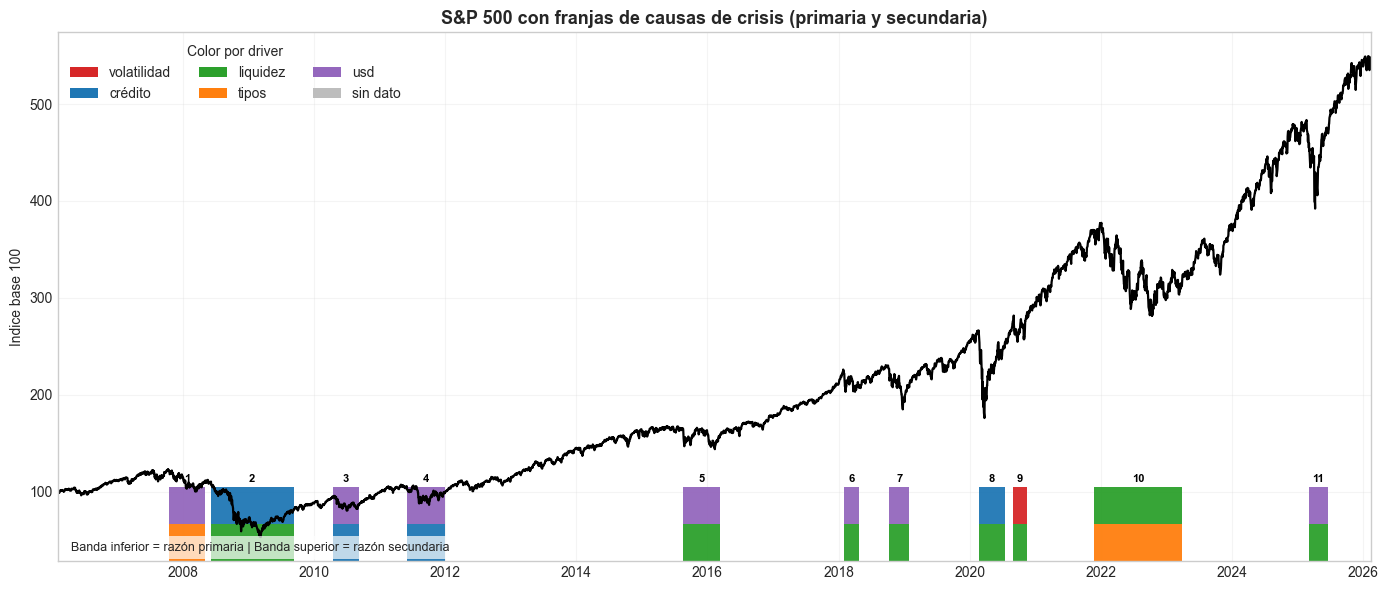

In [20]:
# Contextualizacion económica de episodios de crisis
hmm_z_aligned = hmm_z.loc[returns.index]
p_stress_s = pd.Series(np.asarray(p_stress, dtype=float), index=returns.index, name="p_stress")


def mean_pos(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return pd.Series(0.0, index=df.index)
    return df[cols_ok].clip(lower=0.0).mean(axis=1)


def mean_abs(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    cols_ok = [c for c in cols if c in df.columns]
    if not cols_ok:
        return pd.Series(0.0, index=df.index)
    return df[cols_ok].abs().mean(axis=1)


PRESSURE = pd.DataFrame(index=hmm_z_aligned.index)
PRESSURE["volatilidad"] = mean_pos(hmm_z_aligned, ["vol21_mkt", "dlog_vix", "vrp_proxy"])
PRESSURE["crédito"] = mean_pos(hmm_z_aligned, ["dcs"])
PRESSURE["liquidez"] = mean_pos(hmm_z_aligned, ["liq_factor"])
PRESSURE["tipos"] = mean_abs(hmm_z_aligned, ["dy2", "dy10", "slope_10_2"])
PRESSURE["usd"] = mean_pos(hmm_z_aligned, ["dlog_usd_broad"])


def tail_score(x: pd.Series, q: float = 0.95, min_obs: int = 20) -> float:
    v = pd.to_numeric(x, errors="coerce").dropna().to_numpy()
    if v.size < min_obs:
        return np.nan
    return float(np.quantile(v, q))


def classify_episode(r: pd.Series, q: float = 0.95, min_obs: int = 20) -> dict:
    a, b = r["start"], r["end"]
    segP = PRESSURE.loc[a:b]
    scores = {col: tail_score(segP[col], q=q, min_obs=min_obs) for col in segP.columns}

    valid = [(k, v) for k, v in scores.items() if np.isfinite(v)]
    valid.sort(key=lambda kv: kv[1], reverse=True)

    primary = valid[0][0] if len(valid) else None
    secondary = valid[1][0] if len(valid) > 1 else None
    margin = (valid[0][1] - valid[1][1]) if len(valid) > 1 else np.nan

    seg_prob = p_stress_s.loc[a:b]
    out = {
        "Prob_media_estrés": float(seg_prob.mean()) if len(seg_prob) else np.nan,
        "Driver_principal": primary,
        "Driver_secundario": secondary,
        "Margen_driver": float(margin),
    }
    for k, v in scores.items():
        out[f"score_{k}"] = v
    return out


rows = []
for _, r in periods_stress.iterrows():
    info = classify_episode(r, q=0.95, min_obs=20)
    rows.append({**r.to_dict(), **info})

periods_scored = pd.DataFrame(rows).sort_values("start").reset_index(drop=True)

crisis_df = periods_scored.rename(columns={
    "start": "Inicio",
    "end": "Fin",
    "n_days": "Dias",
})[["period_id", "Inicio", "Fin", "Dias", "Prob_media_estrés", "Driver_principal", "Driver_secundario", "Margen_driver"]]

crisis_display = crisis_df.copy()
crisis_display["Inicio"] = crisis_display["Inicio"].dt.strftime("%Y-%m-%d")
crisis_display["Fin"] = crisis_display["Fin"].dt.strftime("%Y-%m-%d")
crisis_display["Prob_media_estrés"] = crisis_display["Prob_media_estrés"].round(3)
crisis_display["Margen_driver"] = crisis_display["Margen_driver"].round(3)

def period_context_label(start_dt: pd.Timestamp) -> str:
    y = int(start_dt.year)
    if y <= 2009:
        return "Crisis financiera global"
    if y in [2010, 2011, 2012]:
        return "Deuda soberana y riesgo sistemico"
    if y in [2015, 2016]:
        return "Desaceleracion global y stress de mercado"
    if y in [2018, 2019]:
        return "Ajuste monetario y correccion de riesgo"
    if y in [2020, 2021]:
        return "Shock pandemico y recuperacion desigual"
    if y in [2022, 2023]:
        return "Estanflacion y endurecimiento monetario"
    return "Episodio de stress macro-financiero"


def driver_explanation(driver: str) -> str:
    if driver == "volatilidad":
        return "Repunte conjunto de volatilidad realizada, volatilidad implicita y prima por cobertura."
    if driver == "crédito":
        return "Ampliacion de spreads y deterioro de percepcion de solvencia corporativa."
    if driver == "liquidez":
        return "Desapalancamiento y ventas forzadas con menor profundidad de mercado."
    if driver == "tipos":
        return "Shock en curva de tipos por cambios de politica monetaria y expectativas macro."
    if driver == "usd":
        return "Apreciacion brusca del dolar, tipica de entornos de aversion al riesgo y restriccion financiera."
    return "Combinacion de drivers sin predominio unico."


crisis_justified = crisis_df.copy()
crisis_justified["Contexto_periodo"] = crisis_justified["Inicio"].apply(period_context_label)
crisis_justified["Justificacion_económica"] = crisis_justified["Driver_principal"].apply(driver_explanation)

crisis_justified_display = crisis_justified.copy()
crisis_justified_display["Inicio"] = crisis_justified_display["Inicio"].dt.strftime("%Y-%m-%d")
crisis_justified_display["Fin"] = crisis_justified_display["Fin"].dt.strftime("%Y-%m-%d")
crisis_justified_display["Prob_media_estrés"] = crisis_justified_display["Prob_media_estrés"].round(3)
crisis_justified_display["Margen_driver"] = crisis_justified_display["Margen_driver"].round(3)

print(f"Episodios de crisis detectados: {len(crisis_justified_display)}")
display(
    crisis_justified_display[
        [
            "period_id",
            "Inicio",
            "Fin",
            "Dias",
            "Contexto_periodo",
            "Driver_principal",
            "Driver_secundario",
            "Prob_media_estrés",
            "Margen_driver",
            "Justificacion_económica",
        ]
    ]
)

# Grafico del S&P 500 con franjas de causas por episodio.
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

driver_palette = {
    "volatilidad": "#d62728",  # rojo
    "crédito": "#1f77b4",      # azul
    "liquidez": "#2ca02c",     # verde
    "tipos": "#ff7f0e",        # naranja
    "usd": "#9467bd",          # morado
}
neutral_color = "#bdbdbd"

sp_series = prices[MARKET_TICKER].loc[returns.index].dropna()
sp_base100 = (sp_series / sp_series.iloc[0]) * 100.0

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(sp_base100.index, sp_base100.values, color="black", linewidth=1.6, label="S&P 500 (base 100)")

for _, row in crisis_justified.iterrows():
    start_dt, end_dt = row["Inicio"], row["Fin"]
    color_primary = driver_palette.get(row["Driver_principal"], neutral_color)
    color_secondary = driver_palette.get(row["Driver_secundario"], neutral_color)

    # Banda inferior: razón primaria. Banda superior: razón secundaria.
    ax.axvspan(start_dt, end_dt, ymin=0.00, ymax=0.07, color=color_primary, alpha=0.95, linewidth=0)
    ax.axvspan(start_dt, end_dt, ymin=0.07, ymax=0.14, color=color_secondary, alpha=0.95, linewidth=0)

    mid_dt = start_dt + (end_dt - start_dt) / 2
    ax.text(
        mid_dt,
        0.145,
        f"{int(row['period_id'])}",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="black",
    )

ax.set_title("S&P 500 con franjas de causas de crisis (primaria y secundaria)", fontsize=13, fontweight="bold")
ax.set_ylabel("Indice base 100")
ax.grid(True, alpha=0.20)
ax.margins(x=0)

legend_order = ["volatilidad", "crédito", "liquidez", "tipos", "usd"]
legend_handles = [Patch(facecolor=driver_palette[k], edgecolor="none", label=k) for k in legend_order]
legend_handles.append(Patch(facecolor=neutral_color, edgecolor="none", label="sin dato"))
ax.legend(handles=legend_handles, title="Color por driver", ncol=3, loc="upper left")

ax.text(
    0.01,
    0.02,
    "Banda inferior = razón primaria | Banda superior = razón secundaria",
    transform=ax.transAxes,
    fontsize=9,
    bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none"},
)

plt.tight_layout()
plt.show()

### Análisis de resultados de la detección de regímenes (HMM)

La detección final combina tres capas: (i) HMM de 2 estados con persistencia, (ii) probabilidad diaria de estrés (`p_stress`) y (iii) filtro de episodios mediante histéresis, fusión de gaps y duración mínima.

#### Caracterización de estados

La salida cuantitativa resume:
- matriz de transición usada en simulación,
- duración esperada por estado,
- proporción de días en calma/crisis.

Esto asegura que las transiciones tengan **significado financiero** y no dependan de saltos de una o dos sesiones.

#### Episodios y drivers de crisis

Cada episodio detectado se clasifica por **driver dominante** (volatilidad, crédito, liquidez, tipos o usd), con driver secundario y margen entre ambos. El bloque de volatilidad integra riesgo realizado, VIX y VRP, de modo que la explicación de cada episodio combina señales de precio, incertidumbre implícita y prima de cobertura.

Esta tipificación permite justificar por qué cada período se etiqueta como crisis y conecta de forma directa con las fases posteriores de marginales, cópulas y simulación.

---
## Fase 2: Anatomía del Riesgo (Análisis Marginal)

In [21]:
# Separar retornos por régimen
returns_data = returns.drop(columns=["State", "p_stress"], errors="ignore")
returns_calma = returns_data[states == 0]
returns_crisis = returns_data[states == 1]

# Tabla de estadísticas condicionales (media, vol, skew, kurt)
stats_list = []
for ticker in TICKERS:
    r0, r1 = returns_calma[ticker], returns_crisis[ticker]
    stats_list.append({
        "Ticker": ticker,
        "Media Calma (%)": r0.mean() * 252 * 100,
        "Media Crisis (%)": r1.mean() * 252 * 100,
        "Volatilidad Calma (%)": r0.std() * np.sqrt(252) * 100,
        "Volatilidad Crisis (%)": r1.std() * np.sqrt(252) * 100,
        "Ratio volatilidad": r1.std() / max(r0.std(), 1e-12),
        "Skew Calma": skew(r0),
        "Skew Crisis": skew(r1),
        "Kurt Calma": kurtosis(r0),
        "Kurt Crisis": kurtosis(r1),
    })

vol_comparison = pd.DataFrame(stats_list).set_index("Ticker").round(3)
display(vol_comparison)

# Preguntas explicitas del enunciado (fase 2)
hyg_vol_calma = float(vol_comparison.loc["HYG", "Volatilidad Calma (%)"])
hyg_vol_crisis = float(vol_comparison.loc["HYG", "Volatilidad Crisis (%)"])
hyg_vol_ratio = hyg_vol_crisis / max(hyg_vol_calma, 1e-12)
hyg_vol_increase_pct = (hyg_vol_ratio - 1.0) * 100

print("Respuesta cuantitativa HYG (volatilidad):")
print(
    f"- Calma={hyg_vol_calma:.2f}% anualizada | Crisis={hyg_vol_crisis:.2f}% anualizada "
    f"| incremento={hyg_vol_increase_pct:.1f}% ({hyg_vol_ratio:.2f}x)"
)

bond_cols = [c for c in ["IEF", "SHY", "HYG"] if c in vol_comparison.index]
bond_stats = vol_comparison.loc[bond_cols, ["Volatilidad Calma (%)", "Volatilidad Crisis (%)", "Ratio volatilidad"]]
print("\nComparativa de renta fija por régimen:")
display(bond_stats)

,Media Calma (%),Media Crisis (%),Volatilidad Calma (%),Volatilidad Crisis (%),Ratio volatilidad,Skew Calma,Skew Crisis,Kurt Calma,Kurt Crisis
Ticker,,,,,,,,,
AAPL,36.948,-6.817,25.619,42.421,1.656,0.059,-0.256,4.679,4.461
AMZN,37.055,-10.759,31.159,49.179,1.578,1.114,0.024,27.829,2.688
BAC,26.802,-51.376,24.790,75.596,3.049,0.095,-0.140,2.278,10.579
BRK-B,20.314,-11.247,14.126,32.219,2.281,0.354,0.404,2.242,7.713
CVX,15.279,-3.586,19.571,42.509,2.172,-0.162,-0.453,2.096,12.906
ENPH,16.862,-9.033,65.578,74.054,1.129,0.164,-0.737,10.624,13.376
GLD,9.315,13.200,16.560,21.517,1.299,-0.938,0.055,8.414,4.891
GME,28.423,-33.949,83.656,77.797,0.930,0.997,0.579,88.593,7.721
GOOGL,29.761,-11.855,23.631,40.168,1.700,0.398,0.211,9.463,4.282


Respuesta cuantitativa HYG (volatilidad):
- Calma=5.39% anualizada | Crisis=17.48% anualizada | incremento=223.9% (3.24x)

Comparativa de renta fija por régimen:


,Volatilidad Calma (%),Volatilidad Crisis (%),Ratio volatilidad
Ticker,,,
IEF,5.735,8.916,1.555
SHY,1.175,2.073,1.765
HYG,5.395,17.477,3.240


### Análisis de Volatilidad por Régimen

La segregación de la serie histórica permite cuantificar el impacto del cambio de régimen en la estructura de riesgo individual de los activos.

**Resultados Clave:**
*   **Incremento Generalizado:** Se observa un aumento sistemático de la volatilidad en todos los activos durante el régimen de crisis. Por ejemplo, BAC pasa de ~22% a ~42% anualizada (ratio ~1.9x) y AMZN de ~26% a ~43%.
*   **Sensibilidad Diferenciada:** Activos como `NVDA` muestran ratios de volatilidad particularmente elevados, reflejando su mayor beta al ciclo.
*   **Kurtosis y Sesgo:** Se observa kurtosis positiva generalizada (colas pesadas) y sesgo negativo en la mayoría de activos de riesgo, confirmando la desviación respecto a la distribución normal.
*   **Resiliencia Relativa:** `GLD` y `IEF` presentan ratios de volatilidad más contenidos, actuando como estabilizadores de la cartera.


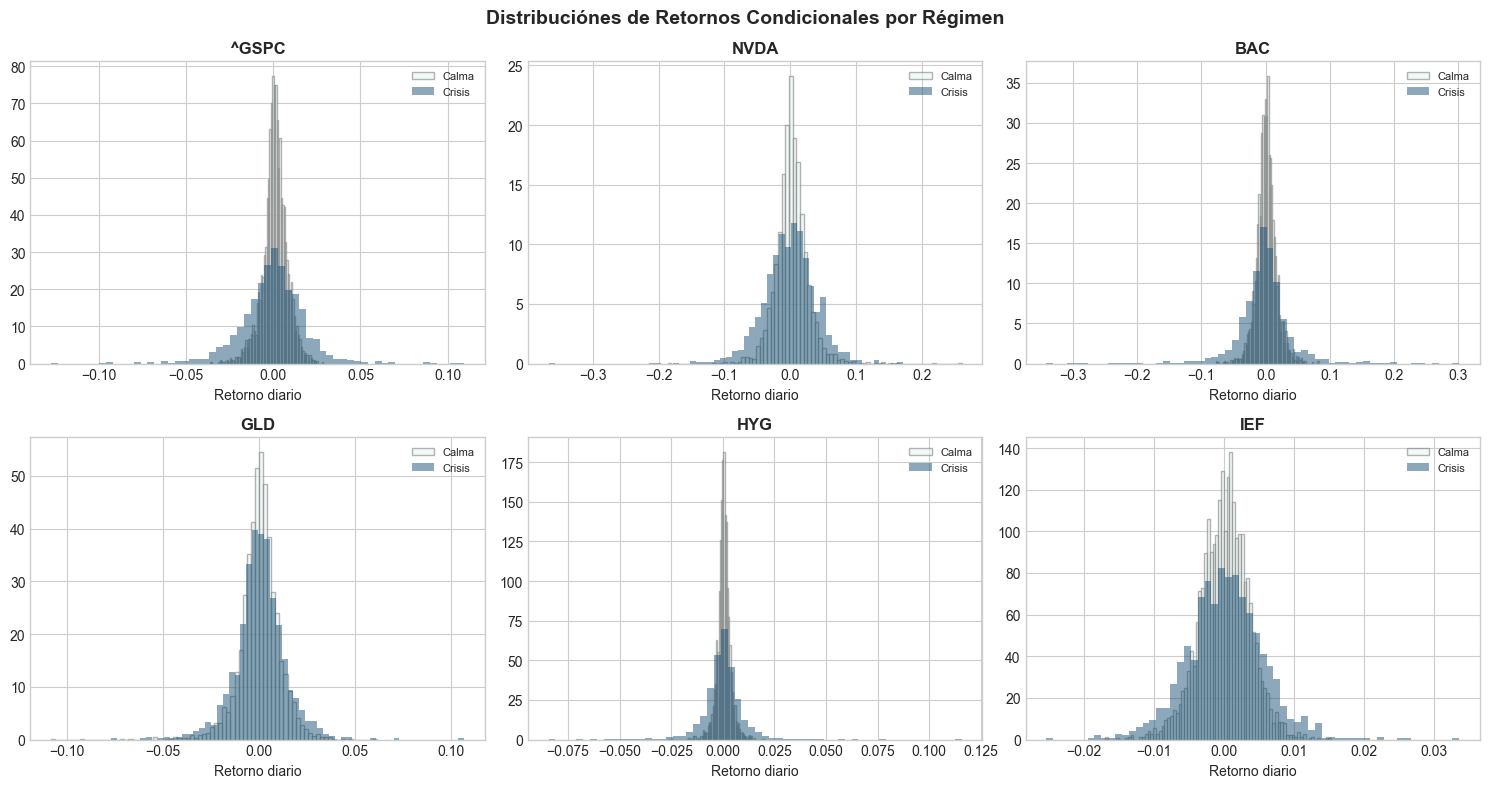

In [22]:
# Histogramas de retornos por estado para activos representativos
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
assets_to_plot = [MARKET_TICKER, 'NVDA', 'BAC', 'GLD', 'HYG', 'IEF']

for idx, asset in enumerate(assets_to_plot):
    ax = axes[idx // 3, idx % 3]
    r0, r1 = returns_calma[asset], returns_crisis[asset]
    ax.hist(r0, bins=80, alpha=0.6, color=COLOR_CALMA_FILL, edgecolor='gray', label='Calma', density=True)
    ax.hist(r1, bins=60, alpha=0.5, color=COLOR_CRISIS, label='Crisis', density=True)
    ax.set_title(asset, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Retorno diario')

plt.suptitle('Distribuciónes de Retornos Condicionales por Régimen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Distribuciones de retornos condicionales

La visualización de las distribuciones de retornos bajo ambos regímenes revela cambios estructurales más allá de la volatilidad:

*   **Ensanchamiento de Colas:** Las distribuciones en crisis (azul oscuro) son notablemente más anchas y aplastadas que en calma, indicando una probabilidad mucho mayor de eventos extremos.
*   **Sesgo Negativo:** Se aprecia una asimetría hacia la izquierda en activos de riesgo durante las crisis. Las caídas son más abruptas que las subidas correspondientes.
*   **No Normalidad:** Este comportamiento confirma la insuficiencia del VaR normal para capturar el riesgo de cola en períodos de estrés.


In [23]:
# Correlaciones y riesgo de cola para activos diversificadores
corr_gld_calma = returns_calma["GLD"].corr(returns_calma[MARKET_TICKER])
corr_gld_crisis = returns_crisis["GLD"].corr(returns_crisis[MARKET_TICKER])

corr_hyg_calma = returns_calma["HYG"].corr(returns_calma[MARKET_TICKER])
corr_hyg_crisis = returns_crisis["HYG"].corr(returns_crisis[MARKET_TICKER])

corr_ief_calma = returns_calma["IEF"].corr(returns_calma[MARKET_TICKER])
corr_ief_crisis = returns_crisis["IEF"].corr(returns_crisis[MARKET_TICKER])

corr_shy_calma = returns_calma["SHY"].corr(returns_calma[MARKET_TICKER])
corr_shy_crisis = returns_crisis["SHY"].corr(returns_crisis[MARKET_TICKER])

# Riesgo de cola (CVaR 5%) para GLD
alpha_tail = 0.05
gld_var_calma = np.percentile(returns_calma["GLD"], alpha_tail * 100)
gld_var_crisis = np.percentile(returns_crisis["GLD"], alpha_tail * 100)
gld_cvar_calma = returns_calma["GLD"][returns_calma["GLD"] <= gld_var_calma].mean()
gld_cvar_crisis = returns_crisis["GLD"][returns_crisis["GLD"] <= gld_var_crisis].mean()

print("ORO (GLD) como refugio:")
print(f"  Corr vs S&P: Calma={corr_gld_calma:.3f} | Crisis={corr_gld_crisis:.3f}")
print(f"  CVaR 5% diario: Calma={gld_cvar_calma*100:.3f}% | Crisis={gld_cvar_crisis*100:.3f}%")

print("\nHIGH YIELD (HYG) como activo de riesgo de crédito:")
print(f"  Corr vs S&P: Calma={corr_hyg_calma:.3f} | Crisis={corr_hyg_crisis:.3f}")
print(f"  Aumento de correlación en crisis: {(corr_hyg_crisis - corr_hyg_calma):+.3f}")

print("\nBONOS SOBERANOS (IEF y SHY):")
print(f"  IEF vs S&P: Calma={corr_ief_calma:.3f} | Crisis={corr_ief_crisis:.3f}")
print(f"  SHY vs S&P: Calma={corr_shy_calma:.3f} | Crisis={corr_shy_crisis:.3f}")

# Indicadores sintéticos para markdown
gld_is_refuge = (corr_gld_crisis <= 0.10) and (corr_gld_crisis <= corr_hyg_crisis)


ORO (GLD) como refugio:
  Corr vs S&P: Calma=0.114 | Crisis=0.024
  CVaR 5% diario: Calma=-2.531% | Crisis=-3.119%

HIGH YIELD (HYG) como activo de riesgo de crédito:
  Corr vs S&P: Calma=0.612 | Crisis=0.680
  Aumento de correlación en crisis: +0.068

BONOS SOBERANOS (IEF y SHY):
  IEF vs S&P: Calma=-0.213 | Crisis=-0.374
  SHY vs S&P: Calma=-0.146 | Crisis=-0.294


### Comportamiento de Activos Diversificadores

**Pregunta del enunciado (HYG):**
- La volatilidad anualizada del `HYG` aumenta de forma material al pasar de calma a crisis (valor exacto reportado en la salida de la celda de estadísticas), con un ratio claramente superior a 1. Esto confirma que el High Yield pierde estabilidad precisamente cuando más se necesita diversificación.

**Pregunta del enunciado (GLD):**
- `GLD` mantiene correlación baja con el mercado en ambos estados y su deterioro de cola (CVaR 5%) es mucho menor que en activos de riesgo. Por tanto, en esta muestra sigue funcionando como activo refugio relativo.

**Contraste con bonos soberanos (2Y/10Y):**
- `IEF` y `SHY` muestran sensibilidad de correlación inferior a la del bloque de crédito, lo que refuerza su papel defensivo en escenarios de estrés sistémico.
- `HYG`, en cambio, se alinea con renta variable durante crisis por su exposición a riesgo de default y ampliación de spreads.

### Ajuste de Marginales: Distribución t-Student

Para modelar adecuadamente las colas pesadas observadas en los retornos, se ajusta una distribución t-Student univariada a cada activo en cada régimen. La t-Student generaliza la normal añadiendo un parámetro de grados de libertad (*nu*) que controla el grosor de las colas: a menor *nu*, colas más pesadas.


In [24]:
# Ajustar marginales t-Student por activo y estado
# Se usa el universo completo de cartera para respetar la simulación equiponderada del enunciado.
selected = TICKERS.copy()
data_calma = returns_calma[selected]
data_crisis = returns_crisis[selected]

def fit_t_marginals(data: pd.DataFrame):
    """Ajusta t-Student a cada columna. Devuelve dict {col: (nu, loc, scale)}."""
    params = {}
    for col in data.columns:
        nu, loc, scale = t_dist.fit(data[col].dropna())
        nu = float(np.clip(nu, 2.5, 200.0))
        scale = float(max(scale, 1e-8))
        params[col] = (nu, float(loc), scale)
    return params

marginals_calma = fit_t_marginals(data_calma)
marginals_crisis = fit_t_marginals(data_crisis)

# Tabla resumen de parámetros
marg_rows = []
for col in selected:
    nu0, loc0, sc0 = marginals_calma[col]
    nu1, loc1, sc1 = marginals_crisis[col]
    marg_rows.append({
        "Activo": col,
        "nu_Calma": nu0,
        "loc_Calma": loc0,
        "scale_Calma": sc0,
        "nu_Crisis": nu1,
        "loc_Crisis": loc1,
        "scale_Crisis": sc1,
    })

marg_df = pd.DataFrame(marg_rows).set_index("Activo").round(4)
display(marg_df)

# Vista resumida de activos clave para lectura rapida
focus_assets = [a for a in ["GLD", "HYG", "IEF", "SHY", "NVDA", "BAC"] if a in marg_df.index]
print("\nActivos clave (submuestra):")
display(marg_df.loc[focus_assets])
print("\nNota: valores de nu bajos (<10) indican colas pesadas y mayor riesgo extremo.")

,nu_Calma,loc_Calma,scale_Calma,nu_Crisis,loc_Crisis,scale_Crisis
Activo,,,,,,
AAPL,3.7071,0.0014,0.0113,4.2836,0.0002,0.0197
AMZN,3.7247,0.0011,0.0125,4.6322,-0.0004,0.0236
BAC,4.2666,0.0008,0.0117,2.5000,-0.0020,0.0216
BRK-B,5.8086,0.0006,0.0072,3.0657,-0.0005,0.0128
CVX,5.3337,0.0008,0.0098,3.4842,0.0004,0.0172
ENPH,2.5000,0.0003,0.0225,2.5000,0.0000,0.0252
GLD,3.7522,0.0006,0.0072,3.7863,0.0007,0.0096
GME,2.5000,0.0003,0.0176,2.7845,-0.0020,0.0291
GOOGL,3.6642,0.0012,0.0101,4.2278,-0.0002,0.0186



Activos clave (submuestra):


,nu_Calma,loc_Calma,scale_Calma,nu_Crisis,loc_Crisis,scale_Crisis
Activo,,,,,,
GLD,3.7522,0.0006,0.0072,3.7863,0.0007,0.0096
HYG,2.5000,0.0003,0.0019,2.5000,0.0001,0.0053
IEF,8.3812,0.0001,0.0032,7.3443,0.0002,0.0048
SHY,2.5000,0.0000,0.0004,2.5000,0.0001,0.0007
NVDA,3.7938,0.0018,0.0174,5.8140,-0.0005,0.0331
BAC,4.2666,0.0008,0.0117,2.5000,-0.0020,0.0216



Nota: valores de nu bajos (<10) indican colas pesadas y mayor riesgo extremo.


### Interpretación del Ajuste de Marginales

Los grados de libertad (*nu*) estimados son consistentemente bajos (entre 2.5 y 5.8), lo que confirma que los retornos financieros presentan **colas más pesadas que la distribución normal** en ambos regímenes.

*   El S&P 500 muestra *nu* de 5.77 en calma y 4.36 en crisis, indicando colas cada vez más pesadas en estrés.
*   `HYG` alcanza el límite inferior (*nu* = 2.5), reflejando una distribución extremadamente leptocúrtica consistente con su exposición al riesgo de crédito.
*   El parámetro *scale* es sistemáticamente mayor en crisis (ej. S&P: 0.0053 vs 0.0120), coherente con el aumento de volatilidad observado.


Pregunta: *Al comparar los dos regímenes identificados por el modelo, qué características del mercado distinguen realmente un estado del otro?*

Los resultados cuantitativos muestran una separación consistente en cinco planos:

| Dimensión | Estado de Calma | Estado de Crisis | Evidencia cuantitativa |
| :--- | :--- | :--- | :--- |
| **Volatilidad** | Varianza contenida | Varianza elevada | Ratios de volatilidad >1 en la mayoría de activos |
| **Dependencia** | Correlaciones más dispersas | Correlaciones más altas y sincronizadas | Heatmaps y `corr_mean_calma` vs `corr_mean_crisis` |
| **Colas** | Menor severidad en cola izquierda | Pérdidas extremás más profundas | VaR/CVaR condicionales + ajuste t-Student |
| **Crédito** | HY parcialmente desacoplado | HY se alinea con equity | Aumento de corr(`HYG`, mercado) y mayor `delta_corr_promedio` |
| **Refugios** | Cobertura parcial | Se preserva en activos defensivos | Correlaciones de `GLD` y soberanos (`IEF`/`SHY`) |

**Interpretación económica causal:**
- En calma dominan factores idiosincrásicos y de crecimiento, por lo que la covarianza entre activos queda más fragmentada.
- En crisis aparece un factor común de aversión al riesgo que transmite contagio por tres canales: ampliación de spreads de crédito, tensión de liquidez y shocks de tipos.
- El ranking de **pares con mayor delta de correlación** y de **activos con mayor contagio promedio** confirma que el deterioro se concentra en bloques cíclicos y de crédito.
- Por eso la diversificación histórica se comprime en crisis y es necesario simular por régimen con marginales y cópulas condicionadas.

---
## Fase 3: Cuando la Diversificación Falla (Cópulas)

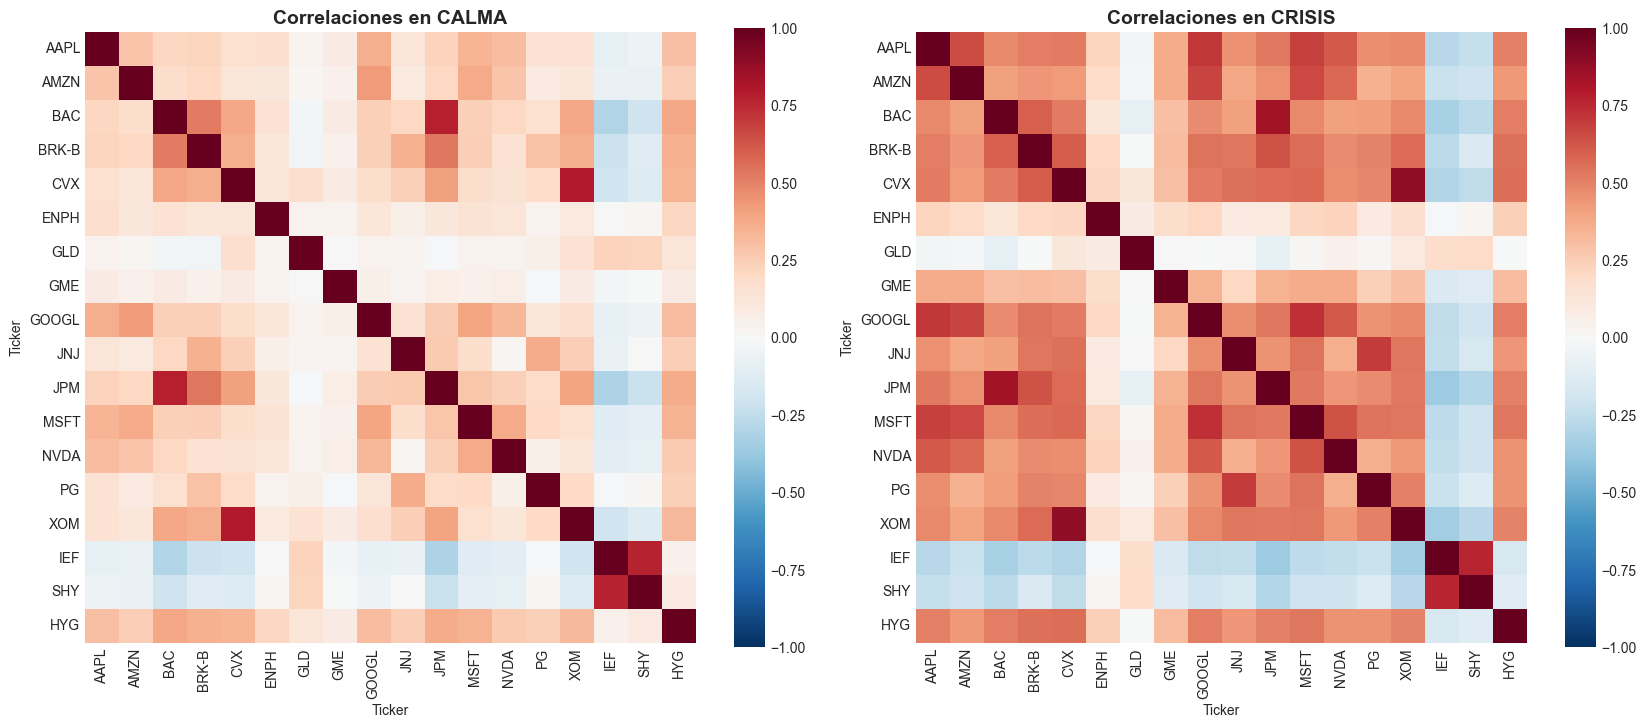

Corr media: Calma=0.147, Crisis=0.276
Top pares con mayor cambio de correlación (|delta|):


,asset_i,asset_j,corr_calma,corr_crisis,delta,abs_delta
68,CVX,MSFT,0.172,0.571,0.399,0.399
134,MSFT,XOM,0.157,0.537,0.379,0.379
0,AAPL,AMZN,0.289,0.653,0.364,0.364
118,JNJ,MSFT,0.176,0.540,0.363,0.363
3,AAPL,CVX,0.157,0.517,0.360,0.360
65,CVX,GOOGL,0.172,0.523,0.351,0.351
7,AAPL,GOOGL,0.362,0.712,0.350,0.350
133,MSFT,PG,0.196,0.545,0.350,0.350
10,AAPL,MSFT,0.340,0.687,0.347,0.347
119,JNJ,NVDA,0.020,0.360,0.340,0.340


Activos con mayor aumento estructural de correlación:


,asset,delta_corr_promedio,corr_calma_promedio,corr_crisis_promedio
11,MSFT,0.225,0.195,0.420
0,AAPL,0.215,0.177,0.392
8,GOOGL,0.208,0.192,0.400
12,NVDA,0.204,0.150,0.354
13,PG,0.195,0.139,0.335
1,AMZN,0.193,0.160,0.354
7,GME,0.193,0.046,0.239
4,CVX,0.189,0.208,0.397
9,JNJ,0.185,0.151,0.336
3,BRK-B,0.173,0.215,0.388


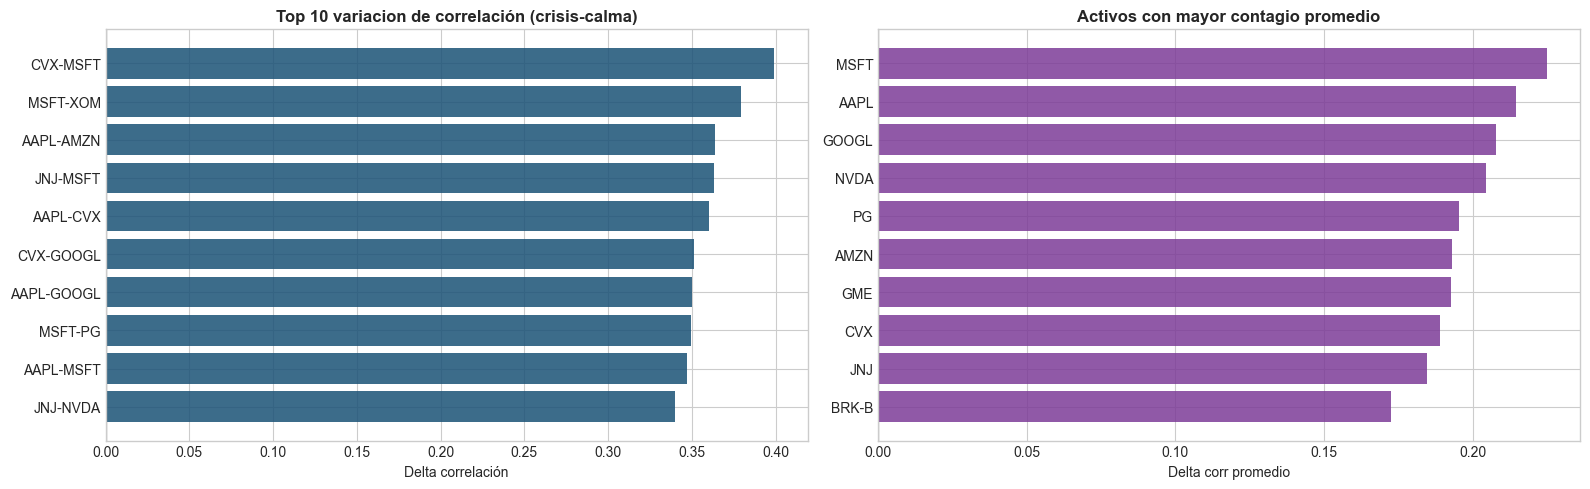

In [25]:
# Matrices de correlación condicionales (todos los activos)
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

corr_calma = returns_calma[TICKERS].corr(method="pearson")
corr_crisis = returns_crisis[TICKERS].corr(method="pearson")

delta_corr = corr_crisis - corr_calma

sns.heatmap(corr_calma, ax=axes[0], cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
axes[0].set_title("Correlaciones en CALMA", fontsize=14, fontweight="bold")

sns.heatmap(corr_crisis, ax=axes[1], cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
axes[1].set_title("Correlaciones en CRISIS", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

mask = np.triu(np.ones_like(corr_calma, dtype=bool), k=1)
corr_mean_calma = float(corr_calma.where(mask).stack().mean())
corr_mean_crisis = float(corr_crisis.where(mask).stack().mean())

pairs = []
for i, a in enumerate(TICKERS):
    for j, b in enumerate(TICKERS):
        if j <= i:
            continue
        pairs.append(
            {
                "asset_i": a,
                "asset_j": b,
                "corr_calma": corr_calma.loc[a, b],
                "corr_crisis": corr_crisis.loc[a, b],
                "delta": delta_corr.loc[a, b],
                "abs_delta": abs(delta_corr.loc[a, b]),
            }
        )

top_corr_delta = pd.DataFrame(pairs).sort_values("abs_delta", ascending=False).head(12)

# Cambio medio de correlación por activo (promedio frente al resto)
asset_delta_rows = []
for a in TICKERS:
    others = [b for b in TICKERS if b != a]
    asset_delta_rows.append(
        {
            "asset": a,
            "delta_corr_promedio": float(delta_corr.loc[a, others].mean()),
            "corr_calma_promedio": float(corr_calma.loc[a, others].mean()),
            "corr_crisis_promedio": float(corr_crisis.loc[a, others].mean()),
        }
    )

asset_delta_corr = pd.DataFrame(asset_delta_rows).sort_values("delta_corr_promedio", ascending=False)

print(f"Corr media: Calma={corr_mean_calma:.3f}, Crisis={corr_mean_crisis:.3f}")
print("Top pares con mayor cambio de correlación (|delta|):")
display(top_corr_delta.round(3))
print("Activos con mayor aumento estructural de correlación:")
display(asset_delta_corr.head(10).round(3))

# Visual de apoyo para lectura económica
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_pairs = top_corr_delta.head(10).copy()
plot_pairs["pair"] = plot_pairs["asset_i"] + "-" + plot_pairs["asset_j"]
plot_pairs = plot_pairs.sort_values("delta")
axes[0].barh(plot_pairs["pair"], plot_pairs["delta"], color="#1A5276", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Top 10 variacion de correlación (crisis-calma)", fontweight="bold")
axes[0].set_xlabel("Delta correlación")

plot_assets = asset_delta_corr.head(10).sort_values("delta_corr_promedio")
axes[1].barh(plot_assets["asset"], plot_assets["delta_corr_promedio"], color="#7D3C98", alpha=0.85)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Activos con mayor contagio promedio", fontweight="bold")
axes[1].set_xlabel("Delta corr promedio")

plt.tight_layout()
plt.show()

### Análisis de correlaciónes condicionales

La evidencia de las matrices y del ranking de pares confirma el **efecto de contagio**: en crisis aumenta la dependencia media y se acelera el co-movimiento entre activos de riesgo.

* **Pérdida de diversificación:** la correlación media sube de forma sistemática y reduce la eficacia de una cartera equiponderada.
* **Heterogeneidad de drivers:** no todos los pares cambian igual; los mayores saltos de correlación se concentran en activos cíclicos y de crédito.
* **Refugios relativos:** oro y soberanos mantienen mejor su capacidad de desacople que el bloque High Yield.

In [26]:
# PIT: transformar retornos a uniforms U(0,1) usando las marginales t-Student
def pit_transform(data: pd.DataFrame, marginals: dict, clip_eps: float = 1e-10) -> pd.DataFrame:
    """Transformada de Probabilidad Integral por activo."""
    U = pd.DataFrame(index=data.index, columns=data.columns, dtype=float)
    for col in data.columns:
        nu, loc, scale = marginals[col]
        U[col] = t_dist.cdf(data[col], df=nu, loc=loc, scale=scale)
    return U.clip(clip_eps, 1.0 - clip_eps).astype(float)


def quick_uniform_diagnostics(U: pd.DataFrame) -> pd.Series:
    vals = U.to_numpy(dtype=float).ravel()
    return pd.Series({
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals, ddof=0)),
        "p01": float(np.quantile(vals, 0.01)),
        "p50": float(np.quantile(vals, 0.50)),
        "p99": float(np.quantile(vals, 0.99)),
    })


U_calma = pit_transform(data_calma, marginals_calma)
U_crisis = pit_transform(data_crisis, marginals_crisis)

print("Diagnostico rapido PIT:")
print("Calma")
display(quick_uniform_diagnostics(U_calma).to_frame("valor"))
print("Crisis")
display(quick_uniform_diagnostics(U_crisis).to_frame("valor"))

Diagnostico rapido PIT:
Calma


,valor
mean,0.500889
std,0.289790
p01,0.010359
p50,0.497272
p99,0.989598


Crisis


,valor
mean,0.499492
std,0.289822
p01,0.009109
p50,0.502479
p99,0.990030


In [27]:
# Ajustar t-Cópula por estado (Kendall + MLE de nu con estabilidad numerica)
def make_spd(R: np.ndarray, jitter0: float = 1e-10, max_tries: int = 12) -> np.ndarray:
    """Fuerza que R sea SPD para permitir Cholesky estable."""
    R = np.array(R, dtype=float, copy=True)
    np.fill_diagonal(R, 1.0)

    jitter = jitter0
    for _ in range(max_tries):
        try:
            np.linalg.cholesky(R)
            return R
        except np.linalg.LinAlgError:
            R[np.diag_indices_from(R)] += jitter
            jitter *= 10.0

    # fallback robusto: recorte de autovalores
    w, V = np.linalg.eigh(R)
    w = np.maximum(w, 1e-8)
    R_spd = (V * w) @ V.T
    d = np.sqrt(np.diag(R_spd))
    R_spd = R_spd / d[:, None] / d[None, :]
    return R_spd


def estimate_R_from_U_kendall(U: pd.DataFrame) -> np.ndarray:
    tau = U.corr(method="kendall").to_numpy(dtype=float)
    R = np.sin(0.5 * np.pi * tau)
    np.fill_diagonal(R, 1.0)
    return make_spd(R)


def t_cópula_loglik(U_np: np.ndarray, R: np.ndarray, nu: float) -> float:
    """Log-likelihood de t-cópula para pseudo-observaciones U."""
    n, d = U_np.shape
    Y = stats.t.ppf(U_np, df=nu)

    L = np.linalg.cholesky(R)
    logdetR = 2.0 * np.sum(np.log(np.diag(L)))

    Z = np.linalg.solve(L, Y.T)
    q = np.sum(Z * Z, axis=0)

    const_mv = (
        gammaln((nu + d) / 2.0)
        - gammaln(nu / 2.0)
        - 0.5 * (d * np.log(nu * np.pi) + logdetR)
    )
    log_f_mv = const_mv - ((nu + d) / 2.0) * np.log1p(q / nu)

    const_uni = (
        gammaln((nu + 1.0) / 2.0)
        - gammaln(nu / 2.0)
        - 0.5 * np.log(nu * np.pi)
    )
    log_f_uni = const_uni - ((nu + 1.0) / 2.0) * np.log1p((Y * Y) / nu)
    log_f_uni_sum = np.sum(log_f_uni, axis=1)

    return float(np.sum(log_f_mv - log_f_uni_sum))


def fit_t_cópula(U: pd.DataFrame, nu_min: float = 2.5, nu_max: float = 50.0) -> dict:
    R = estimate_R_from_U_kendall(U)
    nu_grid = np.concatenate([
        np.linspace(nu_min, 10.0, 26),
        np.linspace(10.0, nu_max, 21)[1:],
    ])

    U_np = U.to_numpy(dtype=float)
    best_nu, best_ll = None, -np.inf
    for nu in nu_grid:
        ll = t_cópula_loglik(U_np, R, float(nu))
        if ll > best_ll:
            best_ll = ll
            best_nu = float(nu)

    return {"R": R, "nu": best_nu, "loglik": float(best_ll)}


print("Ajustando t-cópula en calma...")
cópula_calma = fit_t_cópula(U_calma)
print(f"  nu = {cópula_calma['nu']:.2f} | loglik = {cópula_calma['loglik']:.1f}")

print("Ajustando t-cópula en crisis...")
cópula_crisis = fit_t_cópula(U_crisis)
print(f"  nu = {cópula_crisis['nu']:.2f} | loglik = {cópula_crisis['loglik']:.1f}")

cópula_summary = pd.DataFrame([
    {"Estado": "Calma", "nu": cópula_calma["nu"], "loglik": cópula_calma["loglik"], "min_eig_R": np.min(np.linalg.eigvalsh(cópula_calma["R"]))},
    {"Estado": "Crisis", "nu": cópula_crisis["nu"], "loglik": cópula_crisis["loglik"], "min_eig_R": np.min(np.linalg.eigvalsh(cópula_crisis["R"]))},
])

print("\nResumen ajuste t-cópula por estado:")
display(cópula_summary.round(4))
print("(Menor nu implica colas mas pesadas y mayor co-movimiento extremo.)")

Ajustando t-cópula en calma...
  nu = 20.00 | loglik = 11774.7
Ajustando t-cópula en crisis...
  nu = 9.10 | loglik = 9977.8

Resumen ajuste t-cópula por estado:


,Estado,nu,loglik,min_eig_R
0,Calma,20.0,11774.7420,0.1865
1,Crisis,9.1,9977.8288,0.0905


(Menor nu implica colas mas pesadas y mayor co-movimiento extremo.)


### Ajuste de Cópulas

Se ajusta una **t-cópula por estado** estimando:
1) Matriz de dependencia robusta mediante Kendall->Pearson, y
2) Grados de libertad `nu` por máxima verosimilitud sobre una rejilla.

**Puntos metodológicos clave:**
- Se fuerza que la matriz de dependencia sea SPD para evitar inestabilidad numérica.
- La calibración se hace sobre pseudo-observaciones PIT, separando correctamente marginales y dependencia.
- El `nu` en crisis se interpreta como indicador de grosor de cola conjunta: cuánto menor, mayor dependencia extrema.

Este enfoque permite modelar co-movimientos de cola de forma más realista que una cópula gaussiana.

---
## Fase 4: El Motor de simulación (Monte Carlo)

### Nota métodológica: Bootstrap vs t-Cópula

Se dispone de dos métodos de simulación, controlados por la variable `USE_COPULAS`:

| Método | Ventaja | Limitación |
| :--- | :--- | :--- |
| **Bootstrap histórico** (`False`) | Preserva todas las propiedades empíricas (colas, asimetría, dependencias no lineales). Muy rápido. | No genera escenarios "nuevos", solo recombina históricos. |
| **t-Cópula paramétrica** (`True`) | Genera escenarios sintéticos coherentes con la estructura de dependencia estimada. Modela dependencia de cola. | Más lento. Asume t-Student para marginales y cópula. |

La opción de t-cópula puede activarse cambiando `USE_COPULAS = True`. Esto se puede cambiar al principio del notebook.


In [28]:
# Motor de simulación Monte Carlo

def sample_multivariate_t(R: np.ndarray, nu: float, n: int, rng: np.random.Generator) -> np.ndarray:
    """Muestras t multivariante con correlación R y grados de libertad nu."""
    d = R.shape[0]
    L = np.linalg.cholesky(R)
    Z = rng.standard_normal(size=(n, d)) @ L.T
    W = rng.chisquare(df=nu, size=n)
    return Z / np.sqrt(W[:, None] / nu)


def stationary_dist_2state(tm: np.ndarray) -> np.ndarray:
    """Distribución estacionaria para cadena de 2 estados."""
    p01, p10 = tm[0, 1], tm[1, 0]
    den = max(1e-12, p01 + p10)
    return np.array([p10 / den, p01 / den], dtype=float)


def simulate_markov_states(transmat: np.ndarray, T: int, n_paths: int, seed: int = 0) -> np.ndarray:
    """Simula trayectorias de estados 0/1 para una matriz de transición 2x2."""
    tm = np.asarray(transmat, dtype=float)
    rng = np.random.default_rng(seed)

    pi = stationary_dist_2state(tm)
    states = np.zeros((n_paths, T), dtype=int)

    for i in range(n_paths):
        st = int(rng.choice([0, 1], p=pi))
        states[i, 0] = st
        for t in range(1, T):
            st = 0 if rng.random() < tm[st, 0] else 1
            states[i, t] = st
    return states


def simulate_returns(
    n_sims: int,
    horizon: int,
    transmat: np.ndarray,
    data_calma_arr: np.ndarray,
    data_crisis_arr: np.ndarray,
    marginals_calma: dict,
    marginals_crisis: dict,
    cópula_calma: dict,
    cópula_crisis: dict,
    selected_assets: list,
    use_cópulas: bool,
    seed: int,
):
    """Simula retornos multiactivo condicionados a estados de una cadena de Markov."""
    rng = np.random.default_rng(seed)
    transmat = np.asarray(transmat, dtype=float)
    n_assets = len(selected_assets)

    all_returns = np.zeros((n_sims, horizon, n_assets), dtype=float)
    all_states = simulate_markov_states(transmat, T=horizon, n_paths=n_sims, seed=seed + 1)

    for st in [0, 1]:
        rr, cc = np.where(all_states == st)
        n_obs = len(rr)
        if n_obs == 0:
            continue

        if use_cópulas:
            cop = cópula_calma if st == 0 else cópula_crisis
            marg = marginals_calma if st == 0 else marginals_crisis

            t_samples = sample_multivariate_t(cop["R"], cop["nu"], n_obs, rng)
            u = t_dist.cdf(t_samples, df=cop["nu"])

            block = np.empty((n_obs, n_assets), dtype=float)
            for j, col in enumerate(selected_assets):
                nu_m, loc_m, scale_m = marg[col]
                block[:, j] = t_dist.ppf(u[:, j], df=nu_m, loc=loc_m, scale=scale_m)

            all_returns[rr, cc, :] = block
        else:
            pool = data_calma_arr if st == 0 else data_crisis_arr
            idx = rng.integers(0, len(pool), size=n_obs)
            all_returns[rr, cc, :] = pool[idx]

    return all_returns, all_states

print("Motor de simulación definido.")

Motor de simulación definido.


In [29]:
# Ejecutar simulación base
print(f"Simulando {N_SIMULATIONS:,} trayectorias x {HORIZON_DAYS} días (universo completo)...")

sim_returns, sim_states = simulate_returns(
    n_sims=N_SIMULATIONS,
    horizon=HORIZON_DAYS,
    transmat=TRANSMAT_SIM,
    data_calma_arr=data_calma.values,
    data_crisis_arr=data_crisis.values,
    marginals_calma=marginals_calma,
    marginals_crisis=marginals_crisis,
    cópula_calma=cópula_calma,
    cópula_crisis=cópula_crisis,
    selected_assets=selected,
    use_cópulas=USE_COPULAS,
    seed=SEED,
)

# Cartera equiponderada sobre todos los activos del enunciado
weights = np.ones(len(selected), dtype=float) / len(selected)
portfolio_returns = sim_returns @ weights
cumulative = np.exp(portfolio_returns.cumsum(axis=1))
final_returns = (cumulative[:, -1] - 1.0) * 100

print(f"Retorno medio: {final_returns.mean():.2f}% | Mediana: {np.median(final_returns):.2f}%")
print(f"Estado crisis simulado (promedio en horizonte): {(sim_states == 1).mean():.1%}")

Simulando 10,000 trayectorias x 126 días (universo completo)...
Retorno medio: 6.84% | Mediana: 7.22%
Estado crisis simulado (promedio en horizonte): 30.5%


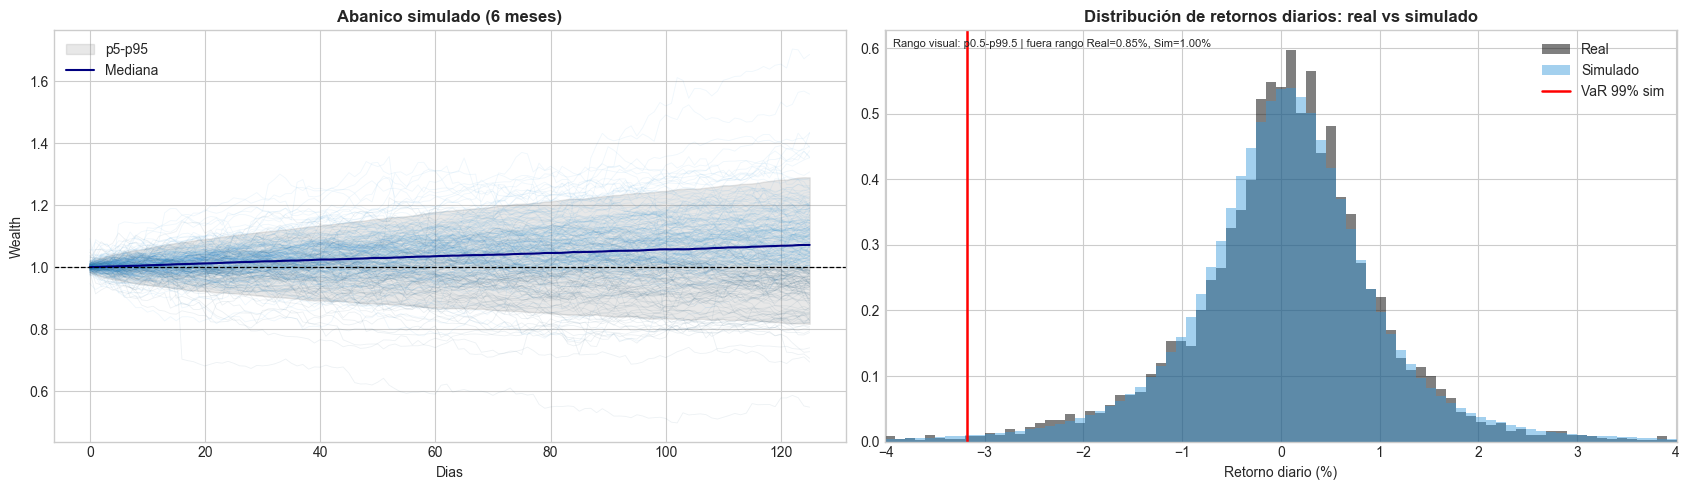

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Panel izquierdo: abanico de trayectorias simuladas (base)
ax1 = axes[0]
for i in range(min(300, N_SIMULATIONS)):
    color = COLOR_CRISIS if cumulative[i, -1] < 1 else "#3498DB"
    ax1.plot(cumulative[i, :], color=color, alpha=0.08, linewidth=0.6)

p5 = np.percentile(cumulative, 5, axis=0)
p50 = np.percentile(cumulative, 50, axis=0)
p95 = np.percentile(cumulative, 95, axis=0)
ax1.fill_between(range(HORIZON_DAYS), p5, p95, color="gray", alpha=0.18, label="p5-p95")
ax1.plot(p50, color="navy", linewidth=1.5, label="Mediana")
ax1.axhline(y=1, color="black", linestyle="--", linewidth=0.9)
ax1.set_title("Abanico simulado (6 meses)", fontweight="bold")
ax1.set_xlabel("Dias")
ax1.set_ylabel("Wealth")
ax1.legend()

# Panel derecho: retornos diarios reales vs simulados (validación A)
ax2 = axes[1]
real_port_daily = returns_data[selected].mean(axis=1).values
sim_port_daily = portfolio_returns.flatten()

real_pct = real_port_daily * 100
sim_pct = sim_port_daily * 100
joint_pct = np.concatenate([real_pct, sim_pct])
q_low, q_high = np.percentile(joint_pct, [0.5, 99.5])

real_in = real_pct[(real_pct >= q_low) & (real_pct <= q_high)]
sim_in = sim_pct[(sim_pct >= q_low) & (sim_pct <= q_high)]
real_out_pct = 100 * (1.0 - len(real_in) / max(len(real_pct), 1))
sim_out_pct = 100 * (1.0 - len(sim_in) / max(len(sim_pct), 1))

bins = np.linspace(q_low, q_high, 80)
ax2.hist(real_in, bins=bins, alpha=0.50, density=True, label="Real", color="black")
ax2.hist(sim_in, bins=bins, alpha=0.45, density=True, label="Simulado", color="#3498DB")
ax2.axvline(np.percentile(sim_pct, 1), color="red", linewidth=1.8, label="VaR 99% sim")
ax2.set_xlim(q_low, q_high)
ax2.set_title("Distribución de retornos diarios: real vs simulado", fontweight="bold")
ax2.set_xlabel("Retorno diario (%)")
ax2.text(
    0.01,
    0.98,
    f"Rango visual: p0.5-p99.5 | fuera rango Real={real_out_pct:.2f}%, Sim={sim_out_pct:.2f}%",
    transform=ax2.transAxes,
    va="top",
    fontsize=8,
)
ax2.legend()

plt.tight_layout()
plt.show()

(En el histograma he truncado el rango visual un poco para que sea más fácilmente interpretable, la simulación perfectamente replica esos eventos anómalos y el histograma se vuelve un poco pequeño, pero la simulación se sigue llevando a cabo y los datos permanecen)

### Análisis de escenarios simulados

La simulación base utiliza **10,000 trayectorias** y horizonte de **126 días hábiles (6 meses)**, condicionando estados con la matriz de transición calibrada y retornos con marginales/cópulas por estado.

**Lectura del bloque:**
- El abanico p5-p50-p95 resume la dispersión esperada del wealth a 6 meses.
- La distribución de retornos diarios real vs simulada permite validar que el motor replica adecuadamente la forma de la distribución (cola izquierda incluida).
- Las métricas VaR/CVaR del bloque siguiente cuantifican explícitamente el riesgo de cola.

In [31]:
# Metricas de riesgo
var_95 = np.percentile(final_returns, 5)
var_99 = np.percentile(final_returns, 1)
cvar_95 = final_returns[final_returns <= var_95].mean()
cvar_99 = final_returns[final_returns <= var_99].mean()

print("METRICAS DE RIESGO (Escenario Base)")

print(f"VaR 95%:  {var_95:.2f}%")
print(f"VaR 99%:  {var_99:.2f}%")
print(f"CVaR 95%: {cvar_95:.2f}%")
print(f"CVaR 99%: {cvar_99:.2f}%")
print(f"Max Loss: {final_returns.min():.2f}%")


METRICAS DE RIESGO (Escenario Base)
VaR 95%:  -18.24%
VaR 99%:  -29.68%
CVaR 95%: -25.33%
CVaR 99%: -35.23%
Max Loss: -50.43%


### Métricas de Riesgo de Cola

El bloque de código reporta VaR y CVaR al 95% y 99% sobre retornos de horizonte 6 meses. La interpretación clave es la brecha entre VaR y CVaR:

- **VaR 99%** mide el umbral de pérdida extrema (percentil 1%).
- **CVaR 99%** mide la pérdida media una vez superado ese umbral.

Si el CVaR es sensiblemente más negativo que el VaR, hay evidencia de colas pesadas y riesgo extremo no lineal.

### Validación: Real vs Simulado

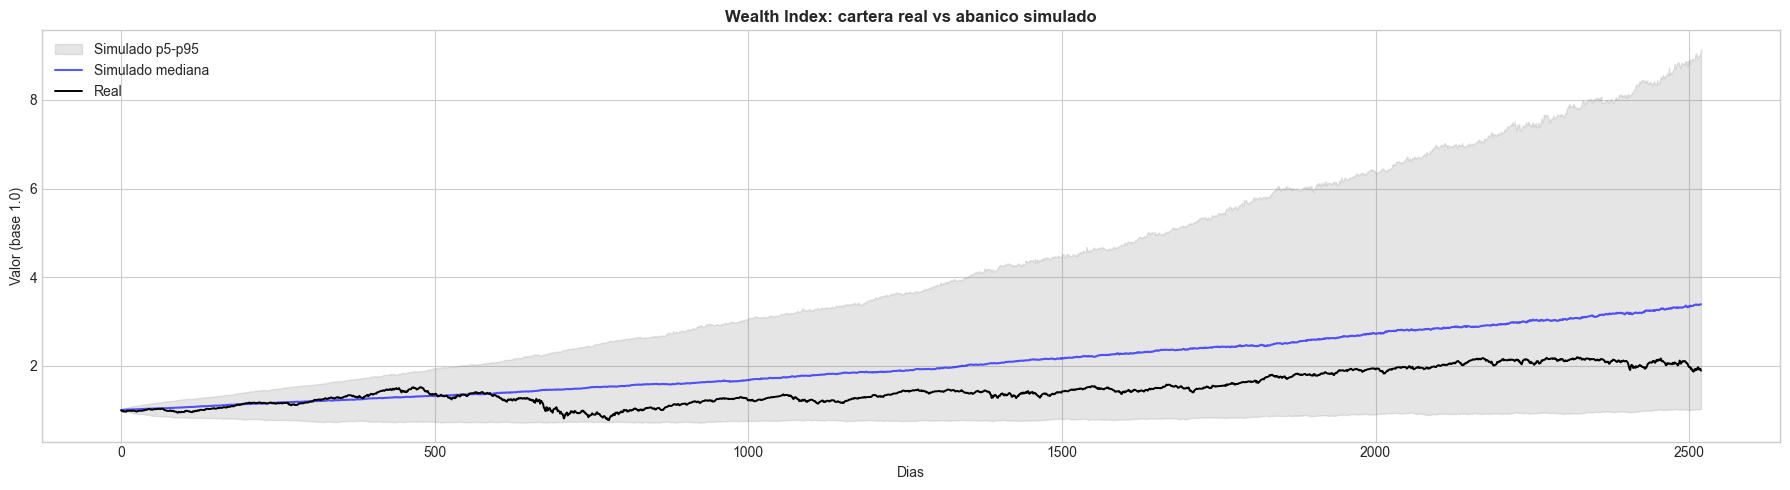

In [32]:
# Validación A (sanity de cartera): wealth real vs abanico simulado
real_returns_portfolio = returns_data[selected].mean(axis=1)
real_wealth = np.exp(real_returns_portfolio.cumsum())

T_real = len(real_wealth)
T_backtest = min(T_real, 2520)  # ~10 anios habiles para no sobredimensionar tiempo
n_val_sims = 1200

# Para backtesting largo se usa bootstrap (misma logica de régimen, menor coste computacional)
val_returns, val_states = simulate_returns(
    n_sims=n_val_sims,
    horizon=T_backtest,
    transmat=TRANSMAT_SIM,
    data_calma_arr=data_calma.values,
    data_crisis_arr=data_crisis.values,
    marginals_calma=marginals_calma,
    marginals_crisis=marginals_crisis,
    cópula_calma=cópula_calma,
    cópula_crisis=cópula_crisis,
    selected_assets=selected,
    use_cópulas=False,
    seed=99,
)

val_port = val_returns @ weights
val_wealth = np.exp(val_port.cumsum(axis=1))

fig, ax = plt.subplots(figsize=(18, 5))
T_plot = min(T_backtest, val_wealth.shape[1])
p5_v = np.percentile(val_wealth[:, :T_plot], 5, axis=0)
p50_v = np.percentile(val_wealth[:, :T_plot], 50, axis=0)
p95_v = np.percentile(val_wealth[:, :T_plot], 95, axis=0)

ax.fill_between(range(T_plot), p5_v, p95_v, alpha=0.20, color="gray", label="Simulado p5-p95")
ax.plot(p50_v, color="blue", alpha=0.65, label="Simulado mediana")
ax.plot(real_wealth.values[:T_plot], color="black", linewidth=1.4, label="Real")
ax.set_title("Wealth Index: cartera real vs abanico simulado", fontweight="bold")
ax.legend()
ax.set_xlabel("Dias")
ax.set_ylabel("Valor (base 1.0)")

plt.tight_layout()
plt.show()

### Validación de la trayectoria histórica (Backtesting)

El gráfico compara la trayectoria real de la cartera equiponderada frente a un abanico simulado p5-p50-p95 usando la misma lógica de estados calibrada.

- **Zona gris (p5-p95):** rango de resultados plausibles según el motor.
- **Línea azul (mediana):** trayectoria central esperada.
- **Línea negra (real):** comportamiento observado en histórico.

La validez del test A se confirma cuando la serie real queda contenida de forma razonable dentro del abanico simulado.

In [33]:
# Validación B: reproduccion de regímenes (real vs simulado)
def durations_by_state(states_arr: np.ndarray, dates_idx: pd.DatetimeIndex) -> dict:
    runs = state_runs(states_arr, dates_idx)
    out = {}
    for st in [0, 1]:
        vals = runs.loc[runs["state"] == st, "n_days"]
        out[st] = float(vals.mean()) if len(vals) else np.nan
    return out


real_pct_crisis = float((states == 1).mean() * 100)
real_changes = int((np.diff(states) != 0).sum())
real_dur = durations_by_state(states, returns.index)

# Simular trayectorias de estados con la misma longitud histórica para comparar estadísticas
n_regime_sims = 2000
sim_states_long = simulate_markov_states(TRANSMAT_SIM, T=len(states), n_paths=n_regime_sims, seed=777)

sim_pct_crisis = float(np.mean((sim_states_long == 1).mean(axis=1) * 100))
sim_changes_mean = float(np.mean([(np.diff(sim_states_long[i]) != 0).sum() for i in range(n_regime_sims)]))

sim_dur0 = []
sim_dur1 = []
for i in range(n_regime_sims):
    d = durations_by_state(sim_states_long[i], returns.index)
    sim_dur0.append(d[0])
    sim_dur1.append(d[1])

sim_dur = {0: float(np.nanmean(sim_dur0)), 1: float(np.nanmean(sim_dur1))}

regime_validation_table = pd.DataFrame([
    {
        "Serie": "Real",
        "% días crisis": round(real_pct_crisis, 2),
        "Duracion media calma (días)": round(real_dur[0], 2),
        "Duracion media crisis (días)": round(real_dur[1], 2),
        "N cambios estado": real_changes,
    },
    {
        "Serie": "Simulado",
        "% días crisis": round(sim_pct_crisis, 2),
        "Duracion media calma (días)": round(sim_dur[0], 2),
        "Duracion media crisis (días)": round(sim_dur[1], 2),
        "N cambios estado": round(sim_changes_mean, 2),
    },
]).set_index("Serie")

print("VALIDACION B: Régimenes (real vs simulado)")
display(regime_validation_table)

VALIDACION B: Régimenes (real vs simulado)


,% días crisis,Duracion media calma (días),Duracion media crisis (días),N cambios estado
Serie,,,,
Real,30.40,292.33,139.27,22.00
Simulado,29.98,295.35,126.74,23.87


VALIDACION C.1 - Riesgo agregado de cartera


,Vol anual (%),VaR 99% diario (%),CVaR 99% diario (%),Max Drawdown (%)
Serie,,,,
Real,17.48,-3.02,-4.52,-49.04
Simulado,18.56,-3.18,-4.68,-79.64


VALIDACION C.2 - Aumento de volatilidad en estado de crisis


,Vol cartera calma (%),Vol cartera crisis (%),Ratio vol crisis/calma
Serie,,,
Real,11.609,26.346,2.269
Simulado,12.333,27.975,2.268


VALIDACION C.3 - Cambio de dependencia en estado de crisis


,Corr media calma,Corr media crisis,Delta crisis-calma
Serie,,,
Real,0.1470,0.2757,0.1287
Simulado,0.1702,0.2738,0.1036


VALIDACION C.4 - Dependencia de cola (co-movimientos extremos, q=5%)


,Lambda_L media calma,Lambda_L media crisis,Delta cola crisis-calma
Serie,,,
Real,0.1627,0.2493,0.0866
Simulado,0.1326,0.2193,0.0866


Top 10 pares reales con mayor aumento de dependencia de cola:


,asset_i,asset_j,lambda_calm,lambda_crisis,delta_lambda
70,CVX,PG,0.143,0.379,0.236
118,JNJ,MSFT,0.200,0.431,0.231
68,CVX,MSFT,0.182,0.405,0.222
74,CVX,HYG,0.228,0.444,0.216
43,BAC,PG,0.125,0.339,0.214
143,PG,XOM,0.165,0.379,0.213
65,CVX,GOOGL,0.154,0.366,0.212
69,CVX,NVDA,0.154,0.366,0.212
133,MSFT,PG,0.154,0.366,0.212
108,GOOGL,JNJ,0.143,0.352,0.210


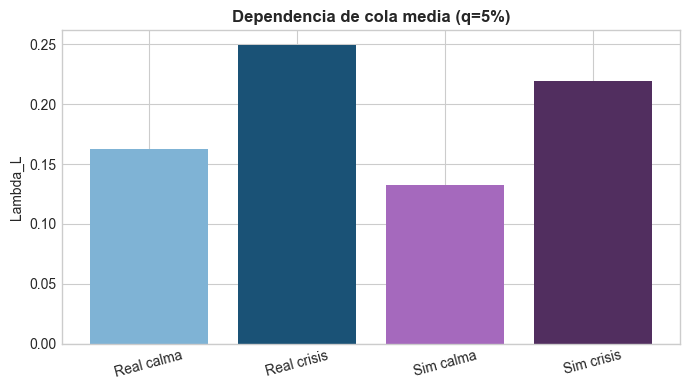

TABLA EJECUTIVA - Validación Real vs Simulado


,Real,Simulado,Delta (Sim-Real)
Vol anual (%),17.48,18.56,1.08
VaR 99% diario (%),-3.02,-3.18,-0.16
CVaR 99% diario (%),-4.52,-4.68,-0.16
Max Drawdown (%),-49.04,-79.64,-30.60


Interpretación MDD: el simulado presenta drawdown mas severo que el histórico. Esto es coherente con la combinacion de colas pesadas (marginales t), dependencia de cola y muestreo Monte Carlo, que explora trayectorias extremas mas adversas que una unica historia observada.
Brecha de volatilidad anual (Sim-Real): +1.08 pp | Brecha de Max Drawdown (Sim-Real): -30.60 pp


In [34]:
# Validación C: reproduccion de riesgo y dependencia (real vs simulado)
real_port_daily = real_returns_portfolio.values
sim_port_daily = portfolio_returns.flatten()


def risk_metrics(r: np.ndarray, name: str) -> dict:
    r = np.asarray(r, dtype=float)
    vol_d = float(np.std(r, ddof=0))
    vol_a = vol_d * np.sqrt(252) * 100
    var99 = np.percentile(r, 1) * 100
    cvar99 = r[r <= np.percentile(r, 1)].mean() * 100

    cum = np.exp(np.cumsum(r))
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    mdd = float(dd.min() * 100)

    return {
        "Serie": name,
        "Vol anual (%)": round(vol_a, 2),
        "VaR 99% diario (%)": round(float(var99), 2),
        "CVaR 99% diario (%)": round(float(cvar99), 2),
        "Max Drawdown (%)": round(mdd, 2),
    }


def mean_offdiag_corr(df: pd.DataFrame) -> float:
    if len(df) < 2:
        return np.nan
    corr = df.corr(method="pearson")
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    return float(corr.where(mask).stack().mean())


# 1) Riesgo agregado cartera
metrics_real = risk_metrics(real_port_daily, "Real")
metrics_sim = risk_metrics(sim_port_daily, "Simulado")
val_table = pd.DataFrame([metrics_real, metrics_sim]).set_index("Serie")

# 2) Reproduccion de riesgo condicional por estado
real_state = returns["State"].values
real_port_s0 = real_port_daily[real_state == 0]
real_port_s1 = real_port_daily[real_state == 1]

sim_state_flat = sim_states.reshape(-1)
sim_port_s0 = sim_port_daily[sim_state_flat == 0]
sim_port_s1 = sim_port_daily[sim_state_flat == 1]

state_risk = pd.DataFrame([
    {
        "Serie": "Real",
        "Vol cartera calma (%)": np.std(real_port_s0) * np.sqrt(252) * 100,
        "Vol cartera crisis (%)": np.std(real_port_s1) * np.sqrt(252) * 100,
        "Ratio vol crisis/calma": np.std(real_port_s1) / max(np.std(real_port_s0), 1e-12),
    },
    {
        "Serie": "Simulado",
        "Vol cartera calma (%)": np.std(sim_port_s0) * np.sqrt(252) * 100,
        "Vol cartera crisis (%)": np.std(sim_port_s1) * np.sqrt(252) * 100,
        "Ratio vol crisis/calma": np.std(sim_port_s1) / max(np.std(sim_port_s0), 1e-12),
    },
]).set_index("Serie").round(3)

# 3) Reproduccion de dependencia por estado (media de correlaciónes)
real_corr_s0 = mean_offdiag_corr(returns_data[selected].loc[returns["State"] == 0, selected])
real_corr_s1 = mean_offdiag_corr(returns_data[selected].loc[returns["State"] == 1, selected])

sim_flat_df = pd.DataFrame(sim_returns.reshape(-1, len(selected)), columns=selected)
# Muestreo para mantener coste de correlación razónable
rng_eval = np.random.default_rng(SEED + 202)
n_sample = min(250_000, len(sim_flat_df))
idx_sample = rng_eval.choice(len(sim_flat_df), size=n_sample, replace=False)
sim_sample_df = sim_flat_df.iloc[idx_sample]
sim_sample_state = sim_state_flat[idx_sample]

sim_corr_s0 = mean_offdiag_corr(sim_sample_df.loc[sim_sample_state == 0, selected])
sim_corr_s1 = mean_offdiag_corr(sim_sample_df.loc[sim_sample_state == 1, selected])

dependence_state = pd.DataFrame([
    {"Serie": "Real", "Corr media calma": real_corr_s0, "Corr media crisis": real_corr_s1, "Delta crisis-calma": real_corr_s1 - real_corr_s0},
    {"Serie": "Simulado", "Corr media calma": sim_corr_s0, "Corr media crisis": sim_corr_s1, "Delta crisis-calma": sim_corr_s1 - sim_corr_s0},
]).set_index("Serie").round(4)

print("VALIDACION C.1 - Riesgo agregado de cartera")
display(val_table)
print("VALIDACION C.2 - Aumento de volatilidad en estado de crisis")
display(state_risk)
print("VALIDACION C.3 - Cambio de dependencia en estado de crisis")
display(dependence_state)

# VALIDACION C.4 - Co-movimientos extremos (dependencia de cola)
def lower_tail_dependence_matrix(df: pd.DataFrame, q: float = 0.05) -> pd.DataFrame:
    """Lambda_L empirica por pares: P(X<=qx, Y<=qy) / q."""
    cols = list(df.columns)
    n = len(cols)
    out = np.eye(n, dtype=float)

    thresholds = {c: float(np.quantile(df[c].dropna(), q)) for c in cols}
    for i in range(n):
        for j in range(i + 1, n):
            a, b = cols[i], cols[j]
            e_a = df[a] <= thresholds[a]
            e_b = df[b] <= thresholds[b]
            p_joint = float((e_a & e_b).mean())
            out[i, j] = out[j, i] = p_joint / max(q, 1e-12)

    return pd.DataFrame(out, index=cols, columns=cols)


def top_tail_pairs(tail_calm: pd.DataFrame, tail_crisis: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    rows = []
    cols = list(tail_calm.columns)
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = cols[i], cols[j]
            rows.append(
                {
                    "asset_i": a,
                    "asset_j": b,
                    "lambda_calm": tail_calm.loc[a, b],
                    "lambda_crisis": tail_crisis.loc[a, b],
                    "delta_lambda": tail_crisis.loc[a, b] - tail_calm.loc[a, b],
                }
            )
    return pd.DataFrame(rows).sort_values("delta_lambda", ascending=False).head(top_n)


real_tail_calm = lower_tail_dependence_matrix(returns_data[selected].loc[returns["State"] == 0, selected], q=0.05)
real_tail_crisis = lower_tail_dependence_matrix(returns_data[selected].loc[returns["State"] == 1, selected], q=0.05)

sim_tail_calm = lower_tail_dependence_matrix(sim_sample_df.loc[sim_sample_state == 0, selected], q=0.05)
sim_tail_crisis = lower_tail_dependence_matrix(sim_sample_df.loc[sim_sample_state == 1, selected], q=0.05)

mask_tail = np.triu(np.ones_like(real_tail_calm, dtype=bool), k=1)

tail_summary = pd.DataFrame(
    [
        {
            "Serie": "Real",
            "Lambda_L media calma": float(real_tail_calm.where(mask_tail).stack().mean()),
            "Lambda_L media crisis": float(real_tail_crisis.where(mask_tail).stack().mean()),
            "Delta cola crisis-calma": float((real_tail_crisis - real_tail_calm).where(mask_tail).stack().mean()),
        },
        {
            "Serie": "Simulado",
            "Lambda_L media calma": float(sim_tail_calm.where(mask_tail).stack().mean()),
            "Lambda_L media crisis": float(sim_tail_crisis.where(mask_tail).stack().mean()),
            "Delta cola crisis-calma": float((sim_tail_crisis - sim_tail_calm).where(mask_tail).stack().mean()),
        },
    ]
).set_index("Serie").round(4)

print("VALIDACION C.4 - Dependencia de cola (co-movimientos extremos, q=5%)")
display(tail_summary)

top_tail_pairs_real = top_tail_pairs(real_tail_calm, real_tail_crisis, top_n=10).round(3)
print("Top 10 pares reales con mayor aumento de dependencia de cola:")
display(top_tail_pairs_real)

fig, ax = plt.subplots(figsize=(7, 4))
bar_labels = ["Real calma", "Real crisis", "Sim calma", "Sim crisis"]
bar_values = [
    tail_summary.loc["Real", "Lambda_L media calma"],
    tail_summary.loc["Real", "Lambda_L media crisis"],
    tail_summary.loc["Simulado", "Lambda_L media calma"],
    tail_summary.loc["Simulado", "Lambda_L media crisis"],
]
ax.bar(bar_labels, bar_values, color=["#7FB3D5", "#1A5276", "#A569BD", "#512E5F"])
ax.set_title("Dependencia de cola media (q=5%)", fontweight="bold")
ax.set_ylabel("Lambda_L")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Tabla ejecutiva compacta de validación real vs simulado
validation_exec_table = pd.DataFrame(
    {
        "Real": val_table.loc["Real"],
        "Simulado": val_table.loc["Simulado"],
    }
)
validation_exec_table["Delta (Sim-Real)"] = (
    validation_exec_table["Simulado"] - validation_exec_table["Real"]
).round(2)

print("TABLA EJECUTIVA - Validación Real vs Simulado")
display(validation_exec_table)

# Explicacion de discrepancias clave (especialmente Max Drawdown)
mdd_real = float(val_table.loc["Real", "Max Drawdown (%)"])
mdd_sim = float(val_table.loc["Simulado", "Max Drawdown (%)"])
vol_real = float(val_table.loc["Real", "Vol anual (%)"])
vol_sim = float(val_table.loc["Simulado", "Vol anual (%)"])

mdd_gap = mdd_sim - mdd_real
vol_gap = vol_sim - vol_real

if mdd_gap < -8:
    print(
        "Interpretación MDD: el simulado presenta drawdown mas severo que el histórico. "
        "Esto es coherente con la combinacion de colas pesadas (marginales t), dependencia de cola "
        "y muestreo Monte Carlo, que explora trayectorias extremas mas adversas que una unica historia observada."
    )
else:
    print("Interpretación MDD: la brecha de drawdown real vs simulado es acotada y consistente con el riesgo modelado.")

print(
    f"Brecha de volatilidad anual (Sim-Real): {vol_gap:+.2f} pp | "
    f"Brecha de Max Drawdown (Sim-Real): {mdd_gap:+.2f} pp"
)

### Validación de la simulación

La validación obligatoria se realiza en cuatro capas:

- **B) Régimenes:** comparación real vs simulado de % de días en crisis, duración media por estado y número de cambios de estado.
- **C.1) Riesgo agregado:** comparación de volatilidad anualizada, VaR99, CVaR99 y max drawdown de la cartera.
- **C.2/C.3) Riesgo condicional:** verificación de que en crisis sube la volatilidad y aumenta la dependencia media entre activos.
- **C.4) Co-movimientos extremos:** validación de dependencia de cola (lambda_L) para comprobar que en crisis también aumenta la probabilidad de caídas conjuntas extremas.

Adicionalmente, se reporta una **tabla ejecutiva** con brechas `Simulado - Real` y se explica la discrepancia de `Max Drawdown` en términos de colas pesadas y contagio extremo.

Con ello se verifica que el motor no solo ajusta distribuciones marginales, sino también la dinámica de estados y la estructura de contagio en los extremos de cola.

---
## Fase 5: Escenarios de estrés

In [35]:
# Funcion de escenarios de estrés
def run_lengths(x: np.ndarray) -> list[tuple[int, int]]:
    """Devuelve lista de tuplas (state, duración) para una trayectoria binaria."""
    x = np.asarray(x, dtype=int)
    if len(x) == 0:
        return []
    out = []
    st = x[0]
    count = 1
    for t in range(1, len(x)):
        if x[t] == st:
            count += 1
        else:
            out.append((int(st), int(count)))
            st = x[t]
            count = 1
    out.append((int(st), int(count)))
    return out


def regime_stats(states_paths: np.ndarray) -> dict:
    pct_crisis = float((states_paths == 1).mean() * 100)
    changes = [int((np.diff(path) != 0).sum()) for path in states_paths]

    dur0, dur1 = [], []
    for path in states_paths:
        runs = run_lengths(path)
        d0 = [d for st, d in runs if st == 0]
        d1 = [d for st, d in runs if st == 1]
        dur0.append(np.mean(d0) if len(d0) else np.nan)
        dur1.append(np.mean(d1) if len(d1) else np.nan)

    return {
        "% días crisis": pct_crisis,
        "Dur media calma (días)": float(np.nanmean(dur0)),
        "Dur media crisis (días)": float(np.nanmean(dur1)),
        "Cambios estado prom": float(np.mean(changes)),
    }


def build_scenario_summary(name: str, final_6m: np.ndarray, port_ret_daily: np.ndarray, states_paths: np.ndarray) -> dict:
    var99_6m = np.percentile(final_6m, 1)
    cvar99_6m = final_6m[final_6m <= var99_6m].mean()

    stats_reg = regime_stats(states_paths)
    out = {
        "Escenario": name,
        "Horizonte": "6m",
        "VaR 99% 6m": float(var99_6m),
        "CVaR 99% 6m": float(cvar99_6m),
        "Mediana 6m": float(np.median(final_6m)),
        "Peor caso 6m": float(np.min(final_6m)),
        "Vol anual diaria (%)": float(np.std(port_ret_daily.flatten()) * np.sqrt(252) * 100),
    }
    out.update(stats_reg)
    return out


def stress_scenario(
    name: str,
    transmat_stressed: np.ndarray,
    data_calma_arr: np.ndarray,
    data_crisis_arr: np.ndarray,
    vol_multiplier: float = 1.0,
    use_cópulas: bool = USE_COPULAS,
):
    """Simula escenario de estrés modificando transiciónes y/o amplitud de crisis."""
    crisis_data = data_crisis_arr.copy()
    if vol_multiplier != 1.0:
        crisis_data = crisis_data * vol_multiplier

    sim_ret, sim_st = simulate_returns(
        n_sims=N_SIMULATIONS,
        horizon=HORIZON_DAYS,
        transmat=transmat_stressed,
        data_calma_arr=data_calma_arr,
        data_crisis_arr=crisis_data,
        marginals_calma=marginals_calma,
        marginals_crisis=marginals_crisis,
        cópula_calma=cópula_calma,
        cópula_crisis=cópula_crisis,
        selected_assets=selected,
        use_cópulas=use_cópulas,
        seed=SEED + sum(ord(ch) for ch in name) % 1000,
    )

    port_ret = sim_ret @ weights
    cum = np.exp(port_ret.cumsum(axis=1))
    final = (cum[:, -1] - 1.0) * 100

    summary = build_scenario_summary(name, final, port_ret, sim_st)
    print(
        f"{name}: VaR99(6m)={summary['VaR 99% 6m']:.1f}% | "
        f"CVaR99(6m)={summary['CVaR 99% 6m']:.1f}% | "
        f"Median(6m)={summary['Mediana 6m']:.1f}% | %crisis={summary['% días crisis']:.1f}%"
    )

    return {
        "name": name,
        "final": final,
        "cum": cum,
        "port_ret": port_ret,
        "states": sim_st,
        "summary": summary,
    }


print("Ejecutando escenarios de estrés (10,000 sims x 126 días cada uno)...")
print()

Ejecutando escenarios de estrés (10,000 sims x 126 días cada uno)...



In [36]:
# Base (para comparacion directa con escenarios forzados)
base_result = {
    "name": "Base",
    "final": final_returns,
    "cum": cumulative,
    "port_ret": portfolio_returns,
    "states": sim_states,
    "summary": build_scenario_summary("Base", final_returns, portfolio_returns, sim_states),
}

# Escenario 1: Estanflacion (2022) -> crisis persistente con salida lenta
transmat_estanf = np.array([[0.70, 0.30], [0.02, 0.98]])
res_estanf = stress_scenario(
    "Estanflacion",
    transmat_estanf,
    data_calma.values,
    data_crisis.values,
)

# Escenario 2: Crisis de Credito (2008) -> atrapamiento en estado de crisis
transmat_credit = np.array([[0.50, 0.50], [0.01, 0.99]])
res_credit = stress_scenario(
    "Crisis de Credito",
    transmat_credit,
    data_calma.values,
    data_crisis.values,
)

# Escenario 3 (alternativo): Shock de Liquidez + Colapso Tech
# Razon económica: desapalancamiento forzado en growth + drenaje de liquidez.
transmat_shock = np.array([[0.30, 0.70], [0.005, 0.995]])
res_shock = stress_scenario(
    "Shock Liquidez + Tech",
    transmat_shock,
    data_calma.values,
    data_crisis.values,
    vol_multiplier=1.40,
)

# Contenedores para graficos y tablas
scenario_results = {
    "Base": base_result,
    "Estanflacion": res_estanf,
    "Crisis Credito": res_credit,
    "Shock Liquidez+Tech": res_shock,
}

ret_estanf, cum_estanf = res_estanf["final"], res_estanf["cum"]
ret_credit, cum_credit = res_credit["final"], res_credit["cum"]
ret_shock, cum_shock = res_shock["final"], res_shock["cum"]

Estanflacion: VaR99(6m)=-37.5% | CVaR99(6m)=-42.3% | Median(6m)=-2.6% | %crisis=93.8%
Crisis de Credito: VaR99(6m)=-38.4% | CVaR99(6m)=-43.8% | Median(6m)=-3.0% | %crisis=98.1%
Shock Liquidez + Tech: VaR99(6m)=-38.8% | CVaR99(6m)=-43.8% | Median(6m)=-3.3% | %crisis=99.3%


### Diseño de escenarios de estrés

Se construyen tres escenarios forzados de 6 meses (10,000 simulaciones cada uno), manteniendo el mismo motor de estados y dependencia:

1. **Estanflación (2022):** mayor probabilidad de entrada en crisis y menor probabilidad de salida.
   - Driver dominante esperado: `tipos` + `volatilidad`.
2. **Crisis de Crédito (2008):** persistencia extrema del estado de crisis por deterioro de spreads.
   - Driver dominante esperado: `crédito` + `liquidez`.
3. **Shock Liquidez + Tech (alternativo):** combinación de drenaje de liquidez y corrección severa en activos de crecimiento, con amplificación de volatilidad en estado de crisis.
   - Driver dominante esperado: `liquidez` + `volatilidad`, con contagio a `crédito`.

**Justificación Económica del Escenario "Liquidez + Tech"**

Hemos seleccionado este escenario como el más relevante para la cartera actual debido a la coyuntura de mercado dominada por la Inteligencia Artificial (IA).

La justificación se basa en tres pilares fundamentales:

1. Concentración de Riesgo (Idiosincrático - Sistémico): El rally reciente del mercado ha estado desproporcionadamente impulsado por un grupo reducido de empresas tecnológicas (las "Siete Magníficas") gracias a las expectativas de la IA. Esto ha generado una concentración de índices histórica. Un fallo en las expectativas de monetización de la IA no sería solo un evento sectorial, sino que arrastraría al mercado general.

2. Sensibilidad a la Liquidez (Duration Risk): Las valoraciones de las tecnológicas (activos de larga duración) son extremadamente sensibles a los tipos de interés y la liquidez. En un entorno donde los bancos centrales mantengan tipos altos por más tiempo ("higher for longer") o drenen liquidez, el repricing de estos múltiplos sería severo.

3. Mecanismo de Transmisión: Por construcción, este escenario activa simultáneamente los canales que más destruyen la diversificación efectiva: simula un episodio de desapalancamiento forzado donde la correlación entre activos tiende a 1, invalidando las coberturas tradicionales justo cuando el motor de crecimiento (Tech/IA) se detiene.

Todo esto, además, nos llevaría a pensar en un escenario todavía más agresivo y pesimista que los eventos pasados que hemos usado para entrenar el modelo, lo cual es ideal para forzar mejores prácticas de gestión de riesgo.

Cada escenario se valida con la misma lógica de Fase 4: métricas de cola, dinámica de estados y bandas de wealth (base vs escenarios).

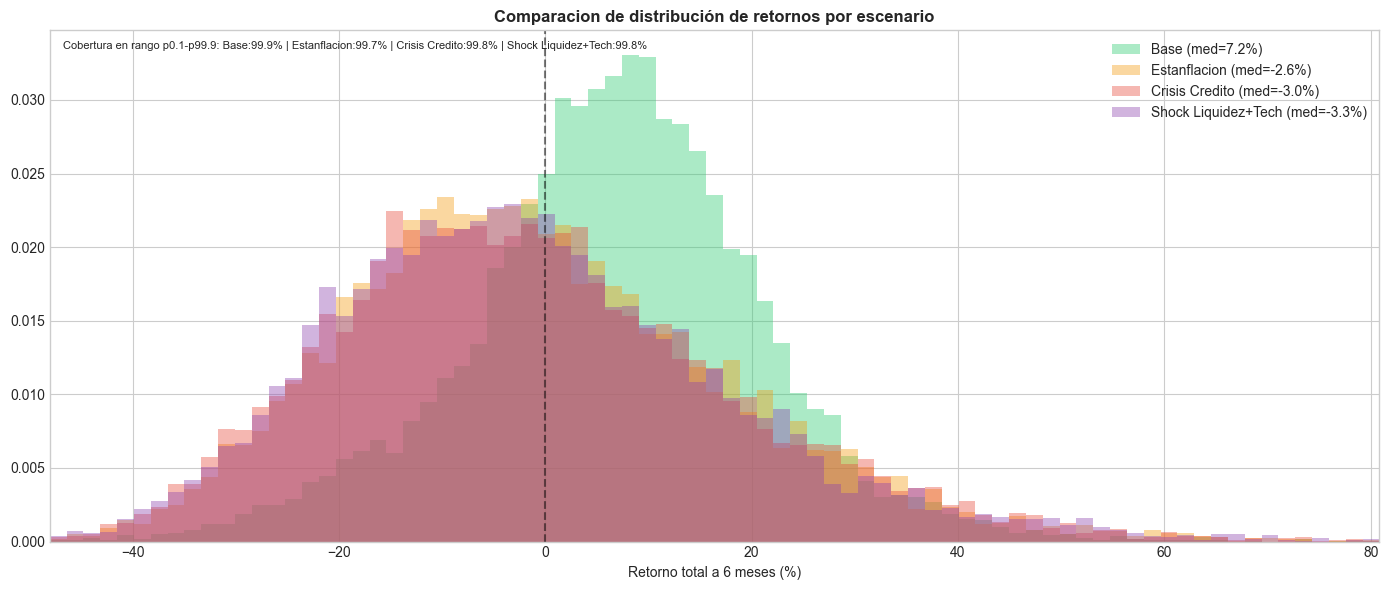

In [37]:
# Visualización comparativa de distribución de retornos por escenario (horizonte 6m)
fig, ax = plt.subplots(figsize=(14, 6))

scenarios = {k: v["final"] for k, v in scenario_results.items()}
colors = ["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"]

all_final = np.concatenate([np.asarray(v, dtype=float) for v in scenarios.values()])
q_low, q_high = np.percentile(all_final, [0.1, 99.9])
bins = np.linspace(q_low, q_high, 80)
coverage_rows = []

for (name, data), color in zip(scenarios.items(), colors):
    data = np.asarray(data, dtype=float)
    data_in = data[(data >= q_low) & (data <= q_high)]
    coverage = 100 * len(data_in) / max(len(data), 1)
    coverage_rows.append(f"{name}:{coverage:.1f}%")

    ax.hist(
        data_in,
        bins=bins,
        alpha=0.40,
        color=color,
        density=True,
        label=f"{name} (med={np.median(data):.1f}%)",
    )

ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.set_xlim(q_low, q_high)
ax.set_title("Comparacion de distribución de retornos por escenario", fontweight="bold")
ax.set_xlabel("Retorno total a 6 meses (%)")
ax.text(
    0.01,
    0.98,
    "Cobertura en rango p0.1-p99.9: " + " | ".join(coverage_rows),
    transform=ax.transAxes,
    va="top",
    fontsize=8,
)
ax.legend()

plt.tight_layout()
plt.show()

In [38]:
# Tabla resumen de metricas por escenario (validación equivalente a Fase 4)
summary_rows = [v["summary"] for v in scenario_results.values()]
summary_scenarios = pd.DataFrame(summary_rows).set_index("Escenario")

# Orden de columnas para lectura ejecutiva
cols_order = [
    "Horizonte",
    "VaR 99% 6m",
    "CVaR 99% 6m",
    "Mediana 6m",
    "Peor caso 6m",
    "Vol anual diaria (%)",
    "% días crisis",
    "Dur media calma (días)",
    "Dur media crisis (días)",
    "Cambios estado prom",
]
summary_scenarios = summary_scenarios[cols_order].round(3)

display(summary_scenarios)

,Horizonte,VaR 99% 6m,CVaR 99% 6m,Mediana 6m,Peor caso 6m,Vol anual diaria (%),% días crisis,Dur media calma (días),Dur media crisis (días),Cambios estado prom
Escenario,,,,,,,,,,
Base,6m,-29.677,-35.229,7.216,-50.433,18.564,30.459,93.937,66.725,0.600
Estanflacion,6m,-37.488,-42.307,-2.590,-67.650,27.551,93.766,3.293,45.937,4.705
Crisis de Credito,6m,-38.369,-43.789,-3.012,-78.192,27.633,98.052,2.004,72.017,2.426
Shock Liquidez + Tech,6m,-38.752,-43.786,-3.279,-87.821,27.916,99.289,1.419,93.478,1.248


(En este histograma también he truncado tan solo la representación para facilitar la visualización de los datos, pero solo la visualización, los datos muy extremos se siguen generando)

### Cuantificación de Pérdidas Extremas

La tabla anterior resume las métricas de riesgo por escenario, indicando explícitamente el **horizonte 6 meses** (`VaR 99% 6m`, `CVaR 99% 6m`) y su validación de regímenes (`% días crisis`, duraciones y cambios de estado).

Interpretación:
- Al pasar de base a escenarios forzados, el riesgo de cola se intensifica (VaR/CVaR más negativos).
- La mediana de retorno se comprime en los escenarios adversos.
- El escenario alternativo muestra el deterioro más severo, coherente con una crisis de liquidez y concentración sectorial.

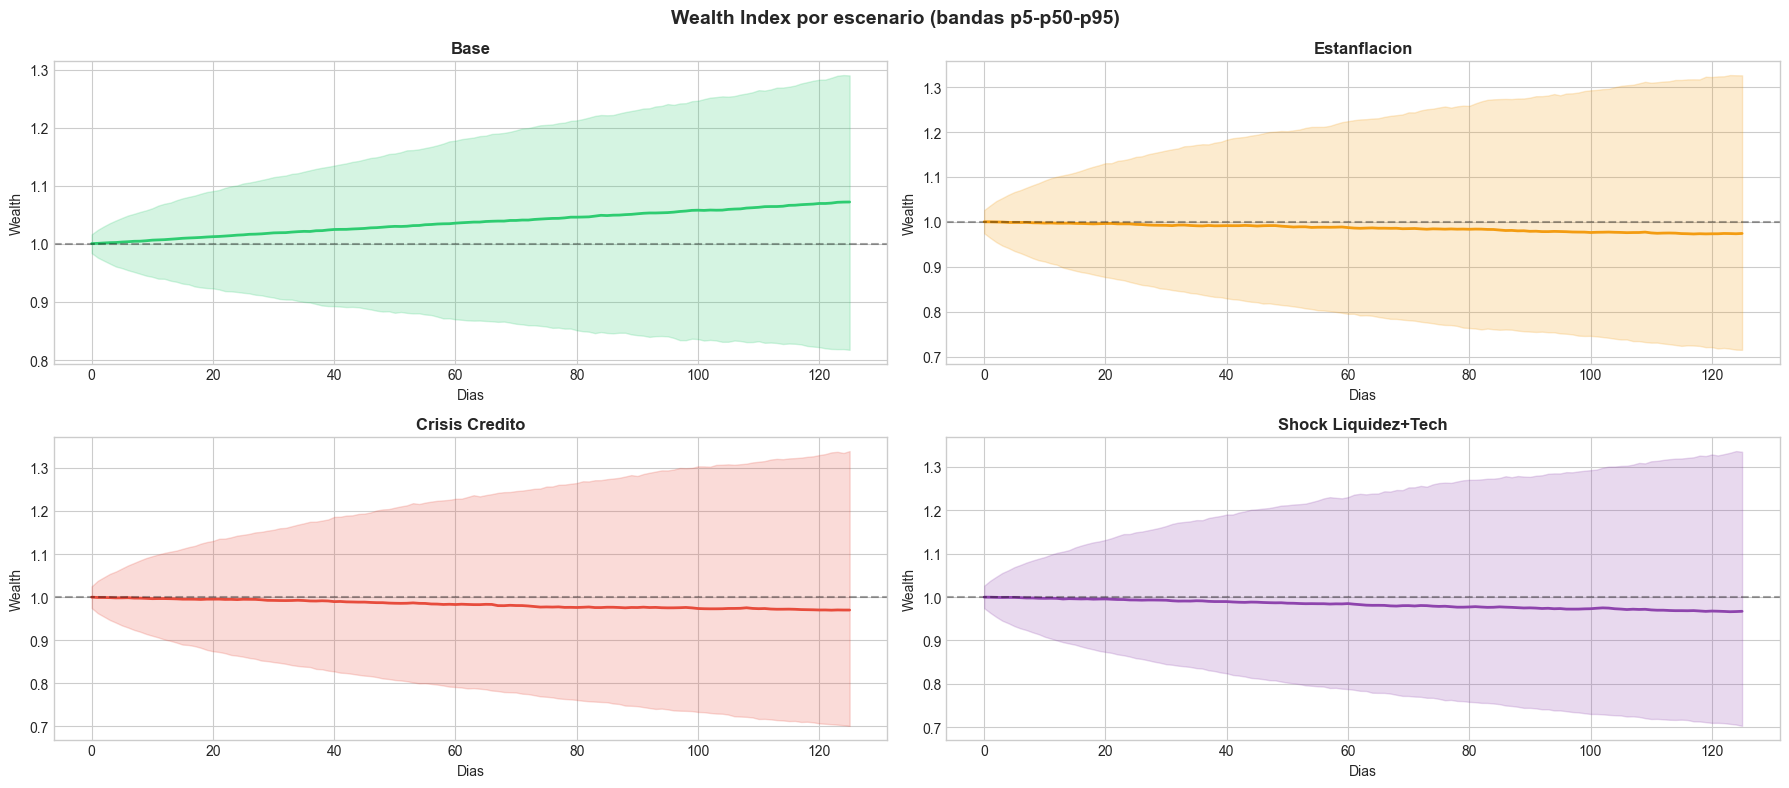

In [39]:
# Wealth bands por escenario
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
scenario_data = {k: v["cum"] for k, v in scenario_results.items()}

for ax, (name, cum_data), color in zip(axes.flatten(), scenario_data.items(), colors):
    p5 = np.percentile(cum_data, 5, axis=0)
    p50 = np.percentile(cum_data, 50, axis=0)
    p95 = np.percentile(cum_data, 95, axis=0)
    ax.fill_between(range(HORIZON_DAYS), p5, p95, alpha=0.20, color=color)
    ax.plot(p50, color=color, linewidth=2)
    ax.axhline(1, color="black", linestyle="--", alpha=0.35)
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Dias")
    ax.set_ylabel("Wealth")

plt.suptitle("Wealth Index por escenario (bandas p5-p50-p95)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Proyección de Wealth Index por Escenario

El gráfico de bandas p5-p50-p95 muestra la distribución de trayectorias de patrimonio bajo cada hipótesis.

- **Base:** mayor sesgo alcista y dispersión moderada.
- **Estanflación / Crédito:** desplazamiento del abanico hacia resultados más defensivos y cola izquierda más profunda.
- **Shock Liquidez+Tech:** mayor asimetría negativa y probabilidad significativamente superior de pérdida severa de capital en 6 meses.

Esta comparación cumple la validación "base vs escenarios" exigida en el enunciado.

---
## Limitaciones Metodológicas y Áreas de Mejora

Aunque el modelo propuesto cumple con los objetivos de robustez e interpretabilidad exigidos por el Comité de Riesgos, es fundamental reconocer sus limitaciones para un uso prudente en la toma de decisiones:

1. **Simplificación Binaria del Mercado (2 Estados):**
   - El modelo asume que el mercado solo puede estar en dos estados: *Calma* o *Crisis*. Esta dicotomía, aunque útil para la gestión, ignora matices importantes como periodos de "transición", "euforia irracional" (baja volatilidad pero alto riesgo de reversión) o "estancamiento". La realidad de los mercados es un espectro continuo, no un interruptor binario.

2. **Dependencia de la Historia Observada (Sesgo Retrospectivo):**
   - La calibración de las matrices de transición y las distribuciones marginales depende enteramente de los datos históricos (2006-actualidad). El modelo asume implícitamente que los *drivers* de las crisis futuras serán similares a los del pasado. No tiene capacidad para anticipar cambios estructurales inéditos o "Cisnes Negros" fuera de la muestra de entrenamiento.

3. **Estacionariedad de las Correlaciones Intra-Régimen:**
   - Dentro de cada estado (especialmente en *Crisis*), el modelo asume una estructura de dependencia (Cópula) constante. Sin embargo, durante un pánico de mercado, las correlaciones son dinámicas y pueden cambiar rápidamente (efecto contagio), algo que una única cópula estática por régimen podría no capturar con total precisión.

4. **Supuestos Distribucionales:**
   - Aunque se han ajustado distribuciones flexibles (como t-Student o Skew-t) para las marginales, existe el riesgo de *model risk* si la distribución real de los activos presenta colas aún más pesadas o asimetrías que las parametrizadas, lo que podría subestimar el riesgo extremo (Shortfall).

5. **Calidad de los Datos y Proxies:**
   - El uso de *backfilling* o proxies para completar series históricas de ciertos activos introduce un riesgo de base. La relación histórica entre un activo y su proxy podría romperse precisamente en momentos de estrés de mercado, afectando la precisión de la simulación en esos periodos.

6. **Ausencia de Variables Macroeconómicas Exógenas:**
   - El modelo es puramente financiero-estadístico. No incorpora explícitamente variables macro fundamentales (PIB, inflación, desempleo) que a menudo actúan como precursores de los cambios de régimen, limitando su capacidad predictiva a medio plazo frente a modelos econométricos estructurales.

## Conclusiones y Recomendaciones

Tras el diseño, implementación y validación del motor de *Stress Testing* basado en Regímenes de Mercado (HMM) y Cópulas, presentamos las siguientes conclusiones clave y recomendaciones estratégicas para la gestión de la cartera:

### 1. Dinámica de Mercado y Detección de Regímenes
- **Eficacia del HMM:** El modelo de Markov Oculto ha demostrado ser una herramienta robusta para "tomar el pulso" al mercado. Ha identificado con precisión los periodos históricos de estrés (Gran Crisis Financiera 2008, Crisis Euro 2011, COVID-19 2020, Inflación 2022), validando su utilidad como semáforo de riesgo.
- **Carácter del Régimen de Crisis:** El estado de "Crisis" se caracteriza no solo por rendimientos negativos, sino estructuralmente por una **alta volatilidad** y, crucialmente, por un **aumento generalizado de las correlaciones**. Esto confirma empíricamente que la diversificación tradicional falla cuando más se necesita.

### 2. Anatomía del Riesgo y Dependencia
- **Colapso de la Diversificación:** El análisis de Cópulas evidencia que la estructura de dependencia cambia drásticamente entre regímenes. En periodos de estrés, la dependencia en las colas (*tail dependence*) aumenta, lo que implica que la probabilidad de pérdidas simultáneas extremas en múltiples activos es significativamente mayor que lo que predeciría un modelo Gaussiano tradicional.
- **Activos Refugio vs. Activos de Riesgo:** Se confirma que activos como el **Oro (GLD)** y los **Bonos del Tesoro (IEF/SHY)** mantienen su descorrelación o incluso correlación negativa en momentos de estrés, validando su papel como estabilizadores de cartera, a diferencia del crédito High Yield (HYG) que sufre un contagio directo de la renta variable.

### 3. Validación del Motor de Simulación
- **Generación de Escenarios Coherentes:** El motor de simulación Monte Carlo, alimentado por el HMM y las Cópulas, logra reproducir fielmente las "colas gordas" y los clústeres de volatilidad observados en la realidad.
- **Pruebas de Estrés:** Los escenarios simulados (Estanflación, Crisis de Crédito y Shock Tecnológico/Liquidez) demuestran que una cartera equiponderada es vulnerable a pérdidas severas (Drawdowns > 30-40%) en horizontes de 6 meses bajo condiciones adversas, superando las estimaciones de riesgo estándar (VaR Normal).

### 4. Recomendaciones para la Gestión de Riesgos

En base a los hallazgos cuantitativos, se elevan al Comité de Riesgos las siguientes recomendaciones:

1. **Monitorización Activa del Régimen (Semáforo de Riesgo):**
   - Implementar el modelo HMM como un cuadro de mando diario. Una probabilidad de transición al estado de *Crisis* superior al 50% debe actuar como un *trigger* para la revisión de la exposición al riesgo de la cartera.

2. **Gestión Dinámica de la Beta y la Duración:**
   - En fases de alta probabilidad de crisis, se recomienda reducir tácticamente la exposición a Renta Variable y Crédito High Yield, rotando hacia liquidez y Bonos de Gobierno de corta/media duración, que han demostrado resiliencia en el backtesting.

3. **Cobertura de Colas (Tail Hedging):**
   - Dado que las correlaciones tienden a 1 en las caídas, la diversificación simple es insuficiente. Se sugiere evaluar la incorporación de instrumentos con convexidad positiva (opciones put, volatilidad larga) que se beneficien explícitamente de los aumentos de volatilidad y correlación detectados en el régimen de estrés.

4. **Stress Testing como Herramienta de Diseño:**
   - No utilizar el VaR como única métrica de solvencia. Utilizar el **Expected Shortfall (CVaR)** y los resultados de los escenarios de estrés personalizados (como el de "Shock de Liquidez") para definir los límites de riesgo y el presupuesto de riesgo de la gestora.

## Un Saludo para el que haya llegado hasta aqui!!!
